In [42]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
from mpltern import TernaryAxes
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import ScalarFormatter
import utils
import matplotlib.gridspec as gridspec
from scipy.signal import detrend
from scipy.stats import pearsonr
import json
import matplotlib
from scipy.interpolate import griddata

%load_ext autoreload 
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Alignment parameter

In [43]:
# read paleoseismic data
paleo_chrono_alignment_DL = pd.read_csv(
    "code_output_data/paleoseismic_alignment_parameters_DL.csv"
)

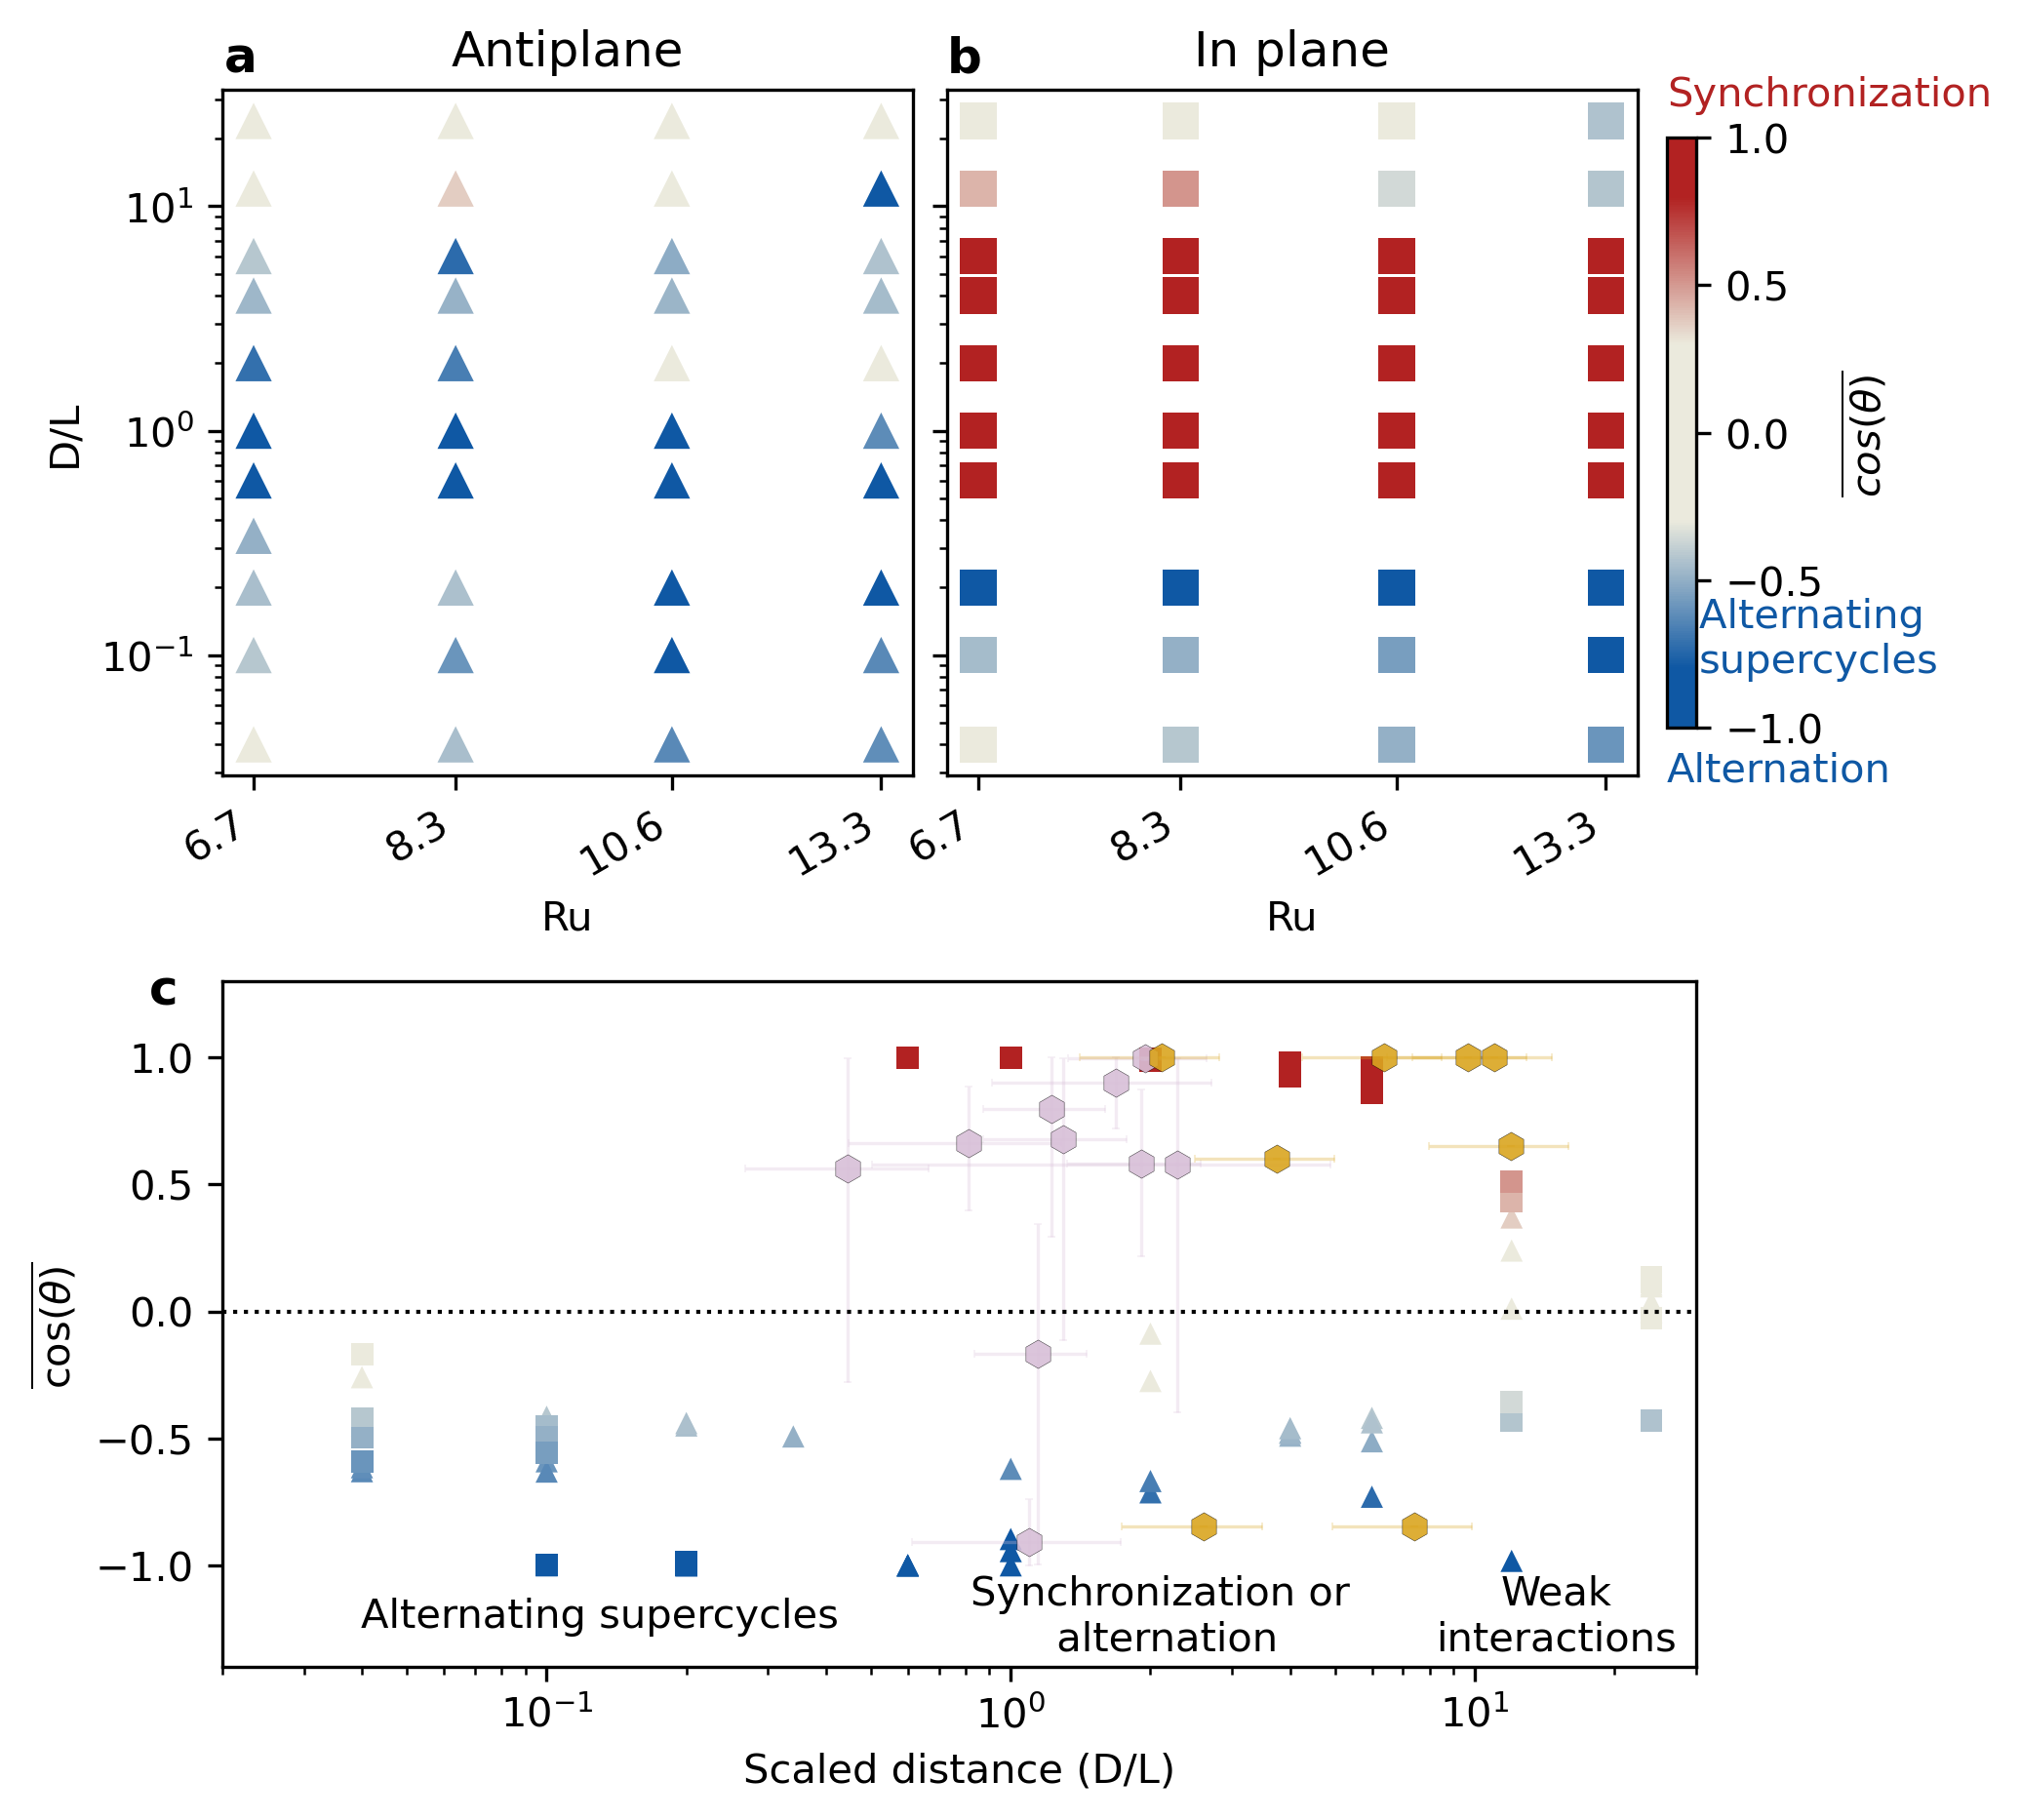

In [44]:
shear_mod = 30e9  # Shear modulus in Pa
a = 1e-2
b = a + 4e-3
sigma_o = 100e6  # normal stress Pa
L = 5000  # rate-weakening length

colors = [
    (0.0, "#0F58A4"),  # -1
    (0.1, "#0F58A4"),  # -0.8
    (0.35, "#EBEADD"),  # -0.3
    (0.65, "#EBEADD"),  # 0.3
    (0.9, "firebrick"),  # 0.8
    (1.0, "firebrick"),  # 1
]
custom_cmap = LinearSegmentedColormap.from_list("custom_RdBu", colors)

order_parameter = pd.read_csv("code_output_data/order_parameter_event_times.csv")

fig = plt.figure(figsize=(6.5, 7), dpi=300)
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], hspace=0.3, wspace=0.05)

# Top row axes
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

scatter = None

for i, (axes, loading, marker) in enumerate(
    zip([ax1, ax2], ["Antiplane", "In plane"], ["^", "s"])
):
    data = order_parameter[
        order_parameter["Loading"].str.strip().str.lower() == loading.lower()
    ].copy()
    data["D"] = pd.to_numeric(data["D"], errors="coerce")
    data["Dc"] = pd.to_numeric(data["Dc"], errors="coerce")
    data["Ru"] = [
        utils.estimate_Ru(shear_mod, dc, b, a, sigma_o, L) for dc in data["Dc"]
    ]

    scatter = axes.scatter(
        data["Ru"],
        data["D"] / 5,
        c=data["Alignment coefficient"],
        cmap=custom_cmap,
        marker=marker,
        vmin=-1,
        vmax=1,
        edgecolor="none",
        s=80,
    )
    axes.set_title(f"{loading}")
    ax1.set_ylabel("D/L")
    axes.set_xlabel("Ru")
    axes.set_xscale("log")
    axes.set_yscale("log")
    axes.set_xticklabels([])
    ax2.set_yticklabels([])
    axes.xaxis.set_minor_locator(plt.NullLocator())

    if loading == "Antiplane":
        desired_ticks = data["Ru"].unique()

cbar = fig.colorbar(
    scatter, ax=[ax1, ax2], orientation="vertical", fraction=0.02, pad=0.02
)
cbar.set_label(r"$\overline{cos(\theta)}$")

ax1.set_xticks(desired_ticks)
ax2.set_xticks(desired_ticks)
ax1.set_xticklabels([f"{tick:.1f}" for tick in desired_ticks], rotation=30, ha="right")
ax2.set_xticklabels([f"{tick:.1f}" for tick in desired_ticks], rotation=30, ha="right")

cbar.ax.text(
    0.0, 1.04, "Synchronization",
    ha="left", va="bottom", fontsize=10,
    transform=cbar.ax.transAxes, color="firebrick",
)
cbar.ax.text(
    0.0, -0.04, "Alternation",
    ha="left", va="top", fontsize=10,
    transform=cbar.ax.transAxes, color="#0F58A4",
)
cbar.ax.text(
    1.1, 0.15, "Alternating \nsupercycles",
    ha="left", va="center", fontsize=10,
    transform=cbar.ax.transAxes, color="#0F58A4",
)

marker_shapes = {"Antiplane": "^", "In plane": "s"}
corr_data = pd.read_csv("code_output_data/order_parameter_event_times.csv")

for _, row in corr_data.iterrows():
    loading = row["Loading"]
    dc = row["Dc"]
    D = row["D"]
    correlation = row["Alignment coefficient"]

    marker = marker_shapes.get(loading, "o")

    ax3.scatter(
        D / (5),
        correlation,
        c=correlation,
        cmap=custom_cmap,
        vmin=-1,
        vmax=1,
        edgecolor="none",
        marker=marker,
        s=30,
    )

# filter to fault1-as-reference rows only (fault2-as-reference goes in supplement)
paleo_chrono_alignment_DL_main = paleo_chrono_alignment_DL[
    paleo_chrono_alignment_DL["reference_fault"] == paleo_chrono_alignment_DL["Fault 1"]
].reset_index(drop=True)

for _, row in paleo_chrono_alignment_DL_main.iterrows():
    x = row["D/L_mean"]
    y = row["ac_mean"]

    if np.isnan(y):
        continue

    x_err_lower = x - row["D/L_min"]
    x_err_upper = row["D/L_max"] - x

    y_err_lower = max(0, y - row["ac_p5"])
    y_err_upper = max(0, row["ac_p95"] - y)

    errplot = ax3.errorbar(
        x, y,
        xerr=[[x_err_lower], [x_err_upper]],
        yerr=[[y_err_lower], [y_err_upper]],
        fmt='h',
        color=row["color"],
        markersize=7,
        capsize=1,
        capthick=0,
        elinewidth=0.8,
        markeredgecolor='k',
        markeredgewidth=0.1
    )

    errplot[0].set_alpha(0.9)
    for bar in errplot[1]:
        bar.set_alpha(1)
    for cap in errplot[2]:
        cap.set_alpha(0.3)

ax3.set_ylabel(r"$\overline{\cos(\theta)}$")
ax3.set_xlabel("Scaled distance (D/L)")
ax3.set_xscale("log")
ax3.set_ylim(-1.4, 1.3)
ax3.set_xlim(0.02, 30)
ax3.axhline(0, color="black", lw=1, linestyle=":")

ax3.text(15, -1.2, "Weak\ninteractions", ha="center", va="center")
ax3.text(0.13, -1.2, "Alternating supercycles", ha="center", va="center")
ax3.text(2.1, -1.2, "Synchronization or\n alternation", ha="center", va="center")

ax1.text(0.05, 1.08, "a", transform=ax1.transAxes, fontsize=12, fontweight="bold", va="top", ha="right")
ax2.text(0.05, 1.08, "b", transform=ax2.transAxes, fontsize=12, fontweight="bold", va="top", ha="right")
ax3.text(-0.03, 1.02, "c", transform=ax3.transAxes, fontsize=12, fontweight="bold", va="top", ha="right")

plt.savefig(
    "Summary figures/interevent_order_plots_tables/alignment_antiplane_inplane.png",
    bbox_inches="tight",
)

### Correlation coefficient

y=-0.267, y_err_lower=0.028, y_err_upper=0.026


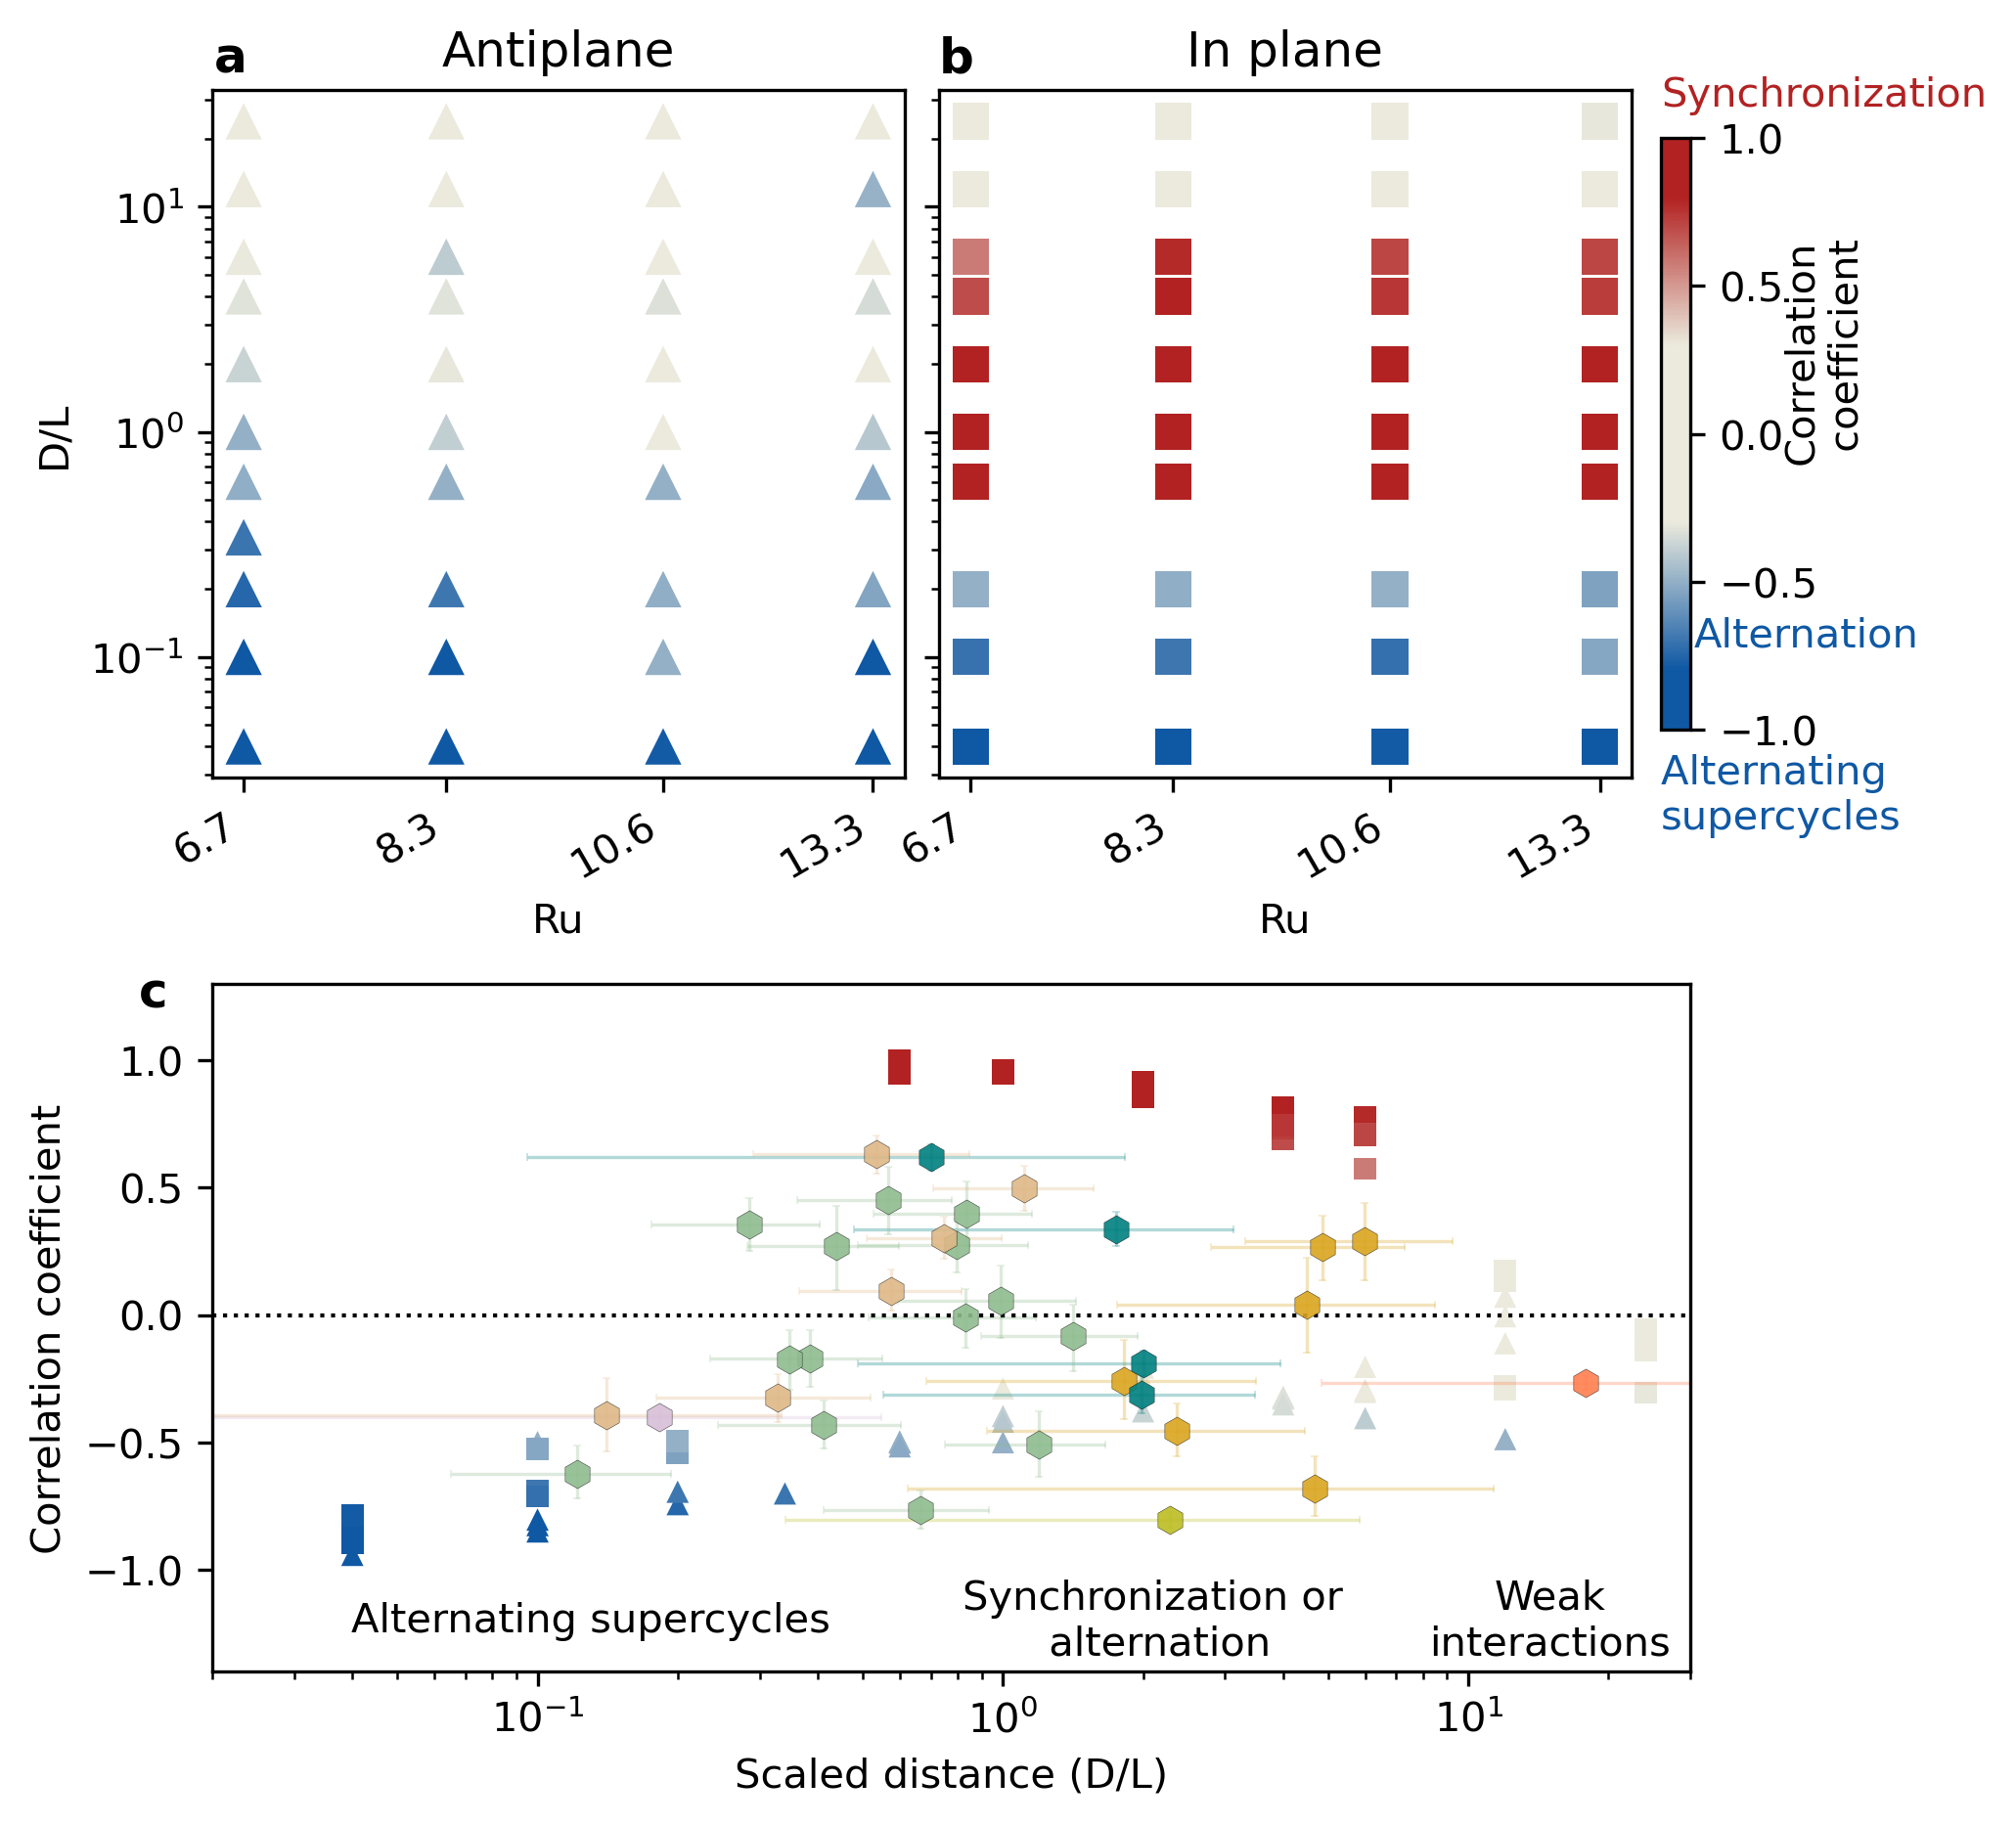

In [45]:

shear_mod = 30e9  # Shear modulus in Pa
a = 1e-2
b = a + 4e-3
sigma_o = 100e6  # normal stress Pa
L = 5000  # rate-weakening length
corr_data = pd.read_csv("code_output_data/corr_coefficient.csv")

colors = [
    (0.0, "#0F58A4"),  # -1
    (0.1, "#0F58A4"),  # -0.8
    (0.35, "#EBEADD"),  # -0.3
    (0.65, "#EBEADD"),  # 0.3
    (0.9, "firebrick"),  # 0.8
    (1.0, "firebrick"),  # 1
]
custom_cmap = LinearSegmentedColormap.from_list("custom_RdBu", colors)

order_parameter = pd.read_csv("code_output_data/order_parameter_event_times.csv")

fig = plt.figure(figsize=(6.5, 7), dpi=300)
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], hspace=0.3, wspace=0.05)

# Top row axes
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

scatter = None

for i, (axes, loading, marker) in enumerate(
    zip([ax1, ax2], ["Antiplane", "In plane"], ["^", "s"])
):
    data = corr_data[
        corr_data["Loading"].str.strip().str.lower() == loading.lower()
    ].copy()
    data["D"] = pd.to_numeric(data["D"], errors="coerce")
    data["Dc"] = pd.to_numeric(data["Dc"], errors="coerce")
    data["Ru"] = [
        utils.estimate_Ru(shear_mod, dc, b, a, sigma_o, L) for dc in data["Dc"]
    ]

    scatter = axes.scatter(
        data["Ru"],
        data["D"] / 5,
        c=data["Correlation coefficient"],
        cmap=custom_cmap,
        marker=marker,
        vmin=-1,
        vmax=1,
        edgecolor="none",
        s=80,
    )
    axes.set_title(f"{loading}")
    ax1.set_ylabel("D/L")
    axes.set_xlabel("Ru")
    axes.set_xscale("log")
    axes.set_yscale("log")
    axes.set_xticklabels([])
    ax2.set_yticklabels([])
    axes.xaxis.set_minor_locator(plt.NullLocator())

    if loading == "Antiplane":
        desired_ticks = data["Ru"].unique()

cbar = fig.colorbar(
    scatter, ax=[ax1, ax2], orientation="vertical", fraction=0.02, pad=0.02
)
cbar.set_label("")
cbar.ax.text(
    4.1,
    0.64,
    "Correlation\n coefficient",
    transform=cbar.ax.transAxes,
    rotation=90,
    va="center",
    ha="left",
    fontsize=10,
)


ax1.set_xticks(desired_ticks)
ax2.set_xticks(desired_ticks)
ax1.set_xticklabels([f"{tick:.1f}" for tick in desired_ticks], rotation=30, ha="right")
ax2.set_xticklabels([f"{tick:.1f}" for tick in desired_ticks], rotation=30, ha="right")

cbar.ax.text(
    0.0,
    1.04,
    "Synchronization",
    ha="left",
    va="bottom",
    fontsize=10,
    transform=cbar.ax.transAxes,
    color="firebrick",
)

cbar.ax.text(
    1.1,
    0.16,
    "Alternation",
    ha="left",
    va="center",
    fontsize=10,
    transform=cbar.ax.transAxes,
    color="#0F58A4",
)

cbar.ax.text(
    0.0,
    -0.04,
    "Alternating \nsupercycles",
    ha="left",
    va="top",
    fontsize=10,
    transform=cbar.ax.transAxes,
    color="#0F58A4",
)

marker_shapes = {"Antiplane": "^", "In plane": "s"}
corr_data = pd.read_csv("code_output_data/corr_coefficient.csv")

for _, row in corr_data.iterrows():
    loading = row["Loading"]
    D = row["D"]
    correlation = row["Correlation coefficient"]

    marker = marker_shapes.get(loading, "o")

    ax3.scatter(
        D / (5),
        correlation,
        c=correlation,
        cmap=custom_cmap,
        vmin=-1,
        vmax=1,
        edgecolor="none",
        marker=marker,
        s=30,
    )


############################################### moment release correlation data
moment_corr_data = pd.read_csv("code_output_data/moment_release_correlation_DL.csv")

for _, row in moment_corr_data.iterrows():
    x = row["D/L_mean"]
    y = row["corr_mean"]

    if np.isnan(y):
        continue

    x_err_lower = x - row["D/L_min"]
    x_err_upper = row["D/L_max"] - x
    y_err_lower = max(0, y - row["corr_p5"])
    y_err_upper = max(0, row["corr_p95"] - y)
    
    print(f"y={y:.3f}, y_err_lower={y_err_lower:.3f}, y_err_upper={y_err_upper:.3f}")

    errplot = ax3.errorbar(
        x, y,
        xerr=[[x_err_lower], [x_err_upper]],
        yerr=[[y_err_lower], [y_err_upper]],
        fmt="h",
        color=row["color"],
        markersize=7,
        capsize=1,
        capthick=0,
        elinewidth=0.8,        # match slip rate
        markeredgecolor='k',   # match slip rate
        markeredgewidth=0.1    # match slip rate
    )

    errplot[0].set_alpha(0.9)
    for bar in errplot[1]:
        bar.set_alpha(1)       # match slip rate
    for cap in errplot[2]:
        cap.set_alpha(0.3)

############################################### slip rate correlation data
slip_rate_corr_data = pd.read_csv("code_output_data/slip_rate_correlation_DL.csv")

for _, row in slip_rate_corr_data.iterrows():
    x = row["D/L_mean"]
    y = row["corr_mean"]

    if np.isnan(y):
        continue

    x_err_lower = x - row["D/L_min"]
    x_err_upper = row["D/L_max"] - x
    y_err_lower = max(0, y - row["corr_p5"])
    y_err_upper = max(0, row["corr_p95"] - y)

    errplot = ax3.errorbar(
        x, y,
        xerr=[[x_err_lower], [x_err_upper]],
        yerr=[[y_err_lower], [y_err_upper]],
        fmt="h",
        color=row["color"],
        markersize=7,
        capsize=1,
        capthick=0,
        elinewidth=0.8,        # match slip rate
        markeredgecolor='k',   # match slip rate
        markeredgewidth=0.1    # match slip rate
    )

    errplot[0].set_alpha(0.9)
    for bar in errplot[1]:
        bar.set_alpha(1)       # match slip rate
    for cap in errplot[2]:
        cap.set_alpha(0.3)

ax3.set_ylabel("Correlation coefficient")
ax3.set_xlabel("Scaled distance (D/L)")
ax3.set_xscale("log")
ax3.set_ylim(-1.4, 1.3)
ax3.set_xlim(0.02, 30)
ax3.axhline(0, color="black", lw=1, linestyle=":")
ax3.text(15, -1.2, "Weak\ninteractions", ha="center", va="center")
ax3.text(0.13, -1.2, "Alternating supercycles", ha="center", va="center")
ax3.text(2.1, -1.2, "Synchronization or\n alternation", ha="center", va="center")

ax1.text(
    0.05,
    1.08,
    "a",
    transform=ax1.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="right",
)
ax2.text(
    0.05,
    1.08,
    "b",
    transform=ax2.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="right",
)
ax3.text(
    -0.03,
    1.02,
    "c",
    transform=ax3.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="right",
)


plt.savefig(
    "Summary figures/interevent_order_plots_tables/correlation_antiplane_inplane.png",
    bbox_inches="tight",
)

### Stress comparison

In [46]:
inplane_partial = json.load(open("stress jsons/inplane_partial_rupture.json"))
inplane_full = json.load(open("stress jsons/inplane_full_rupture.json"))
antiplane_partial = json.load(open("stress jsons/antiplane_partial_rupture.json"))
antiplane_full = json.load(open("stress jsons/antiplane_full_rupture.json"))

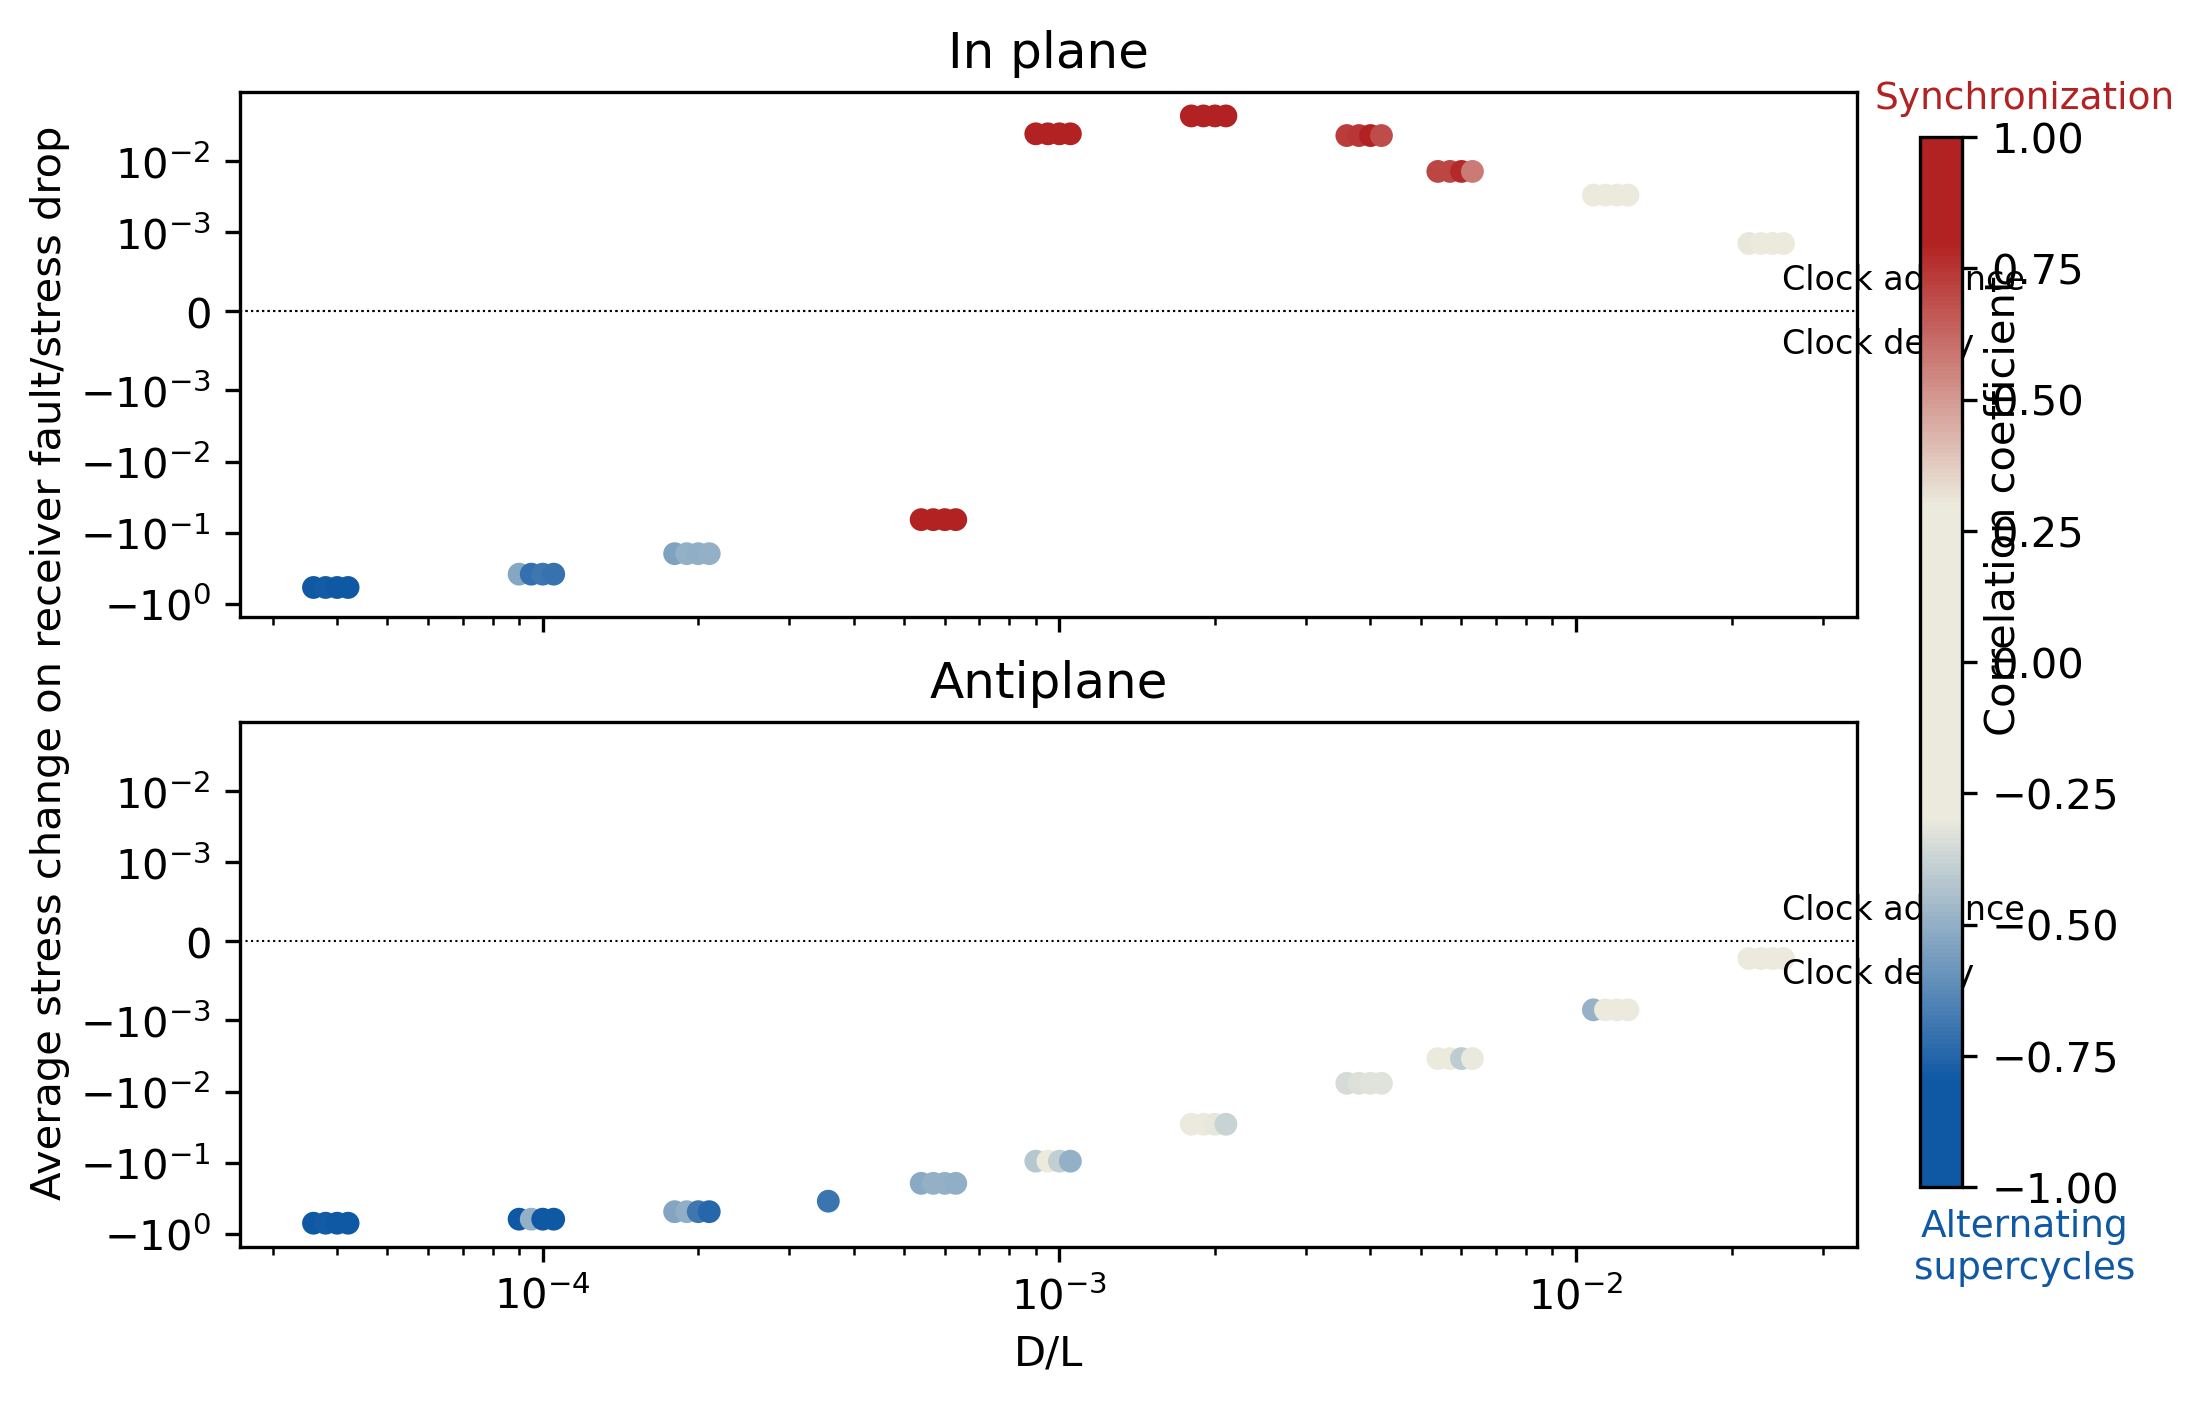

In [47]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5), dpi=300, sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.2)

# Get D values from the JSON (sorted)
D_values_json = np.sort(
    corr_data[corr_data["Loading"].str.strip() == "In plane"]["D"].unique()
)[: len(inplane_full)]

# Calculate average stress for each curve once
avg_stress_inplane = {}
for i, curve in enumerate(inplane_full):
    if i >= len(D_values_json):
        break
    y = [point[1] for point in curve]
    D = D_values_json[i]
    avg_stress_inplane[D] = np.mean(y)

# Plot for each Dc with jitter
inplane_corr = corr_data[corr_data["Loading"].str.strip() == "In plane"].copy()
dc_values = sorted(inplane_corr["Dc"].unique())
n_dc = len(dc_values)

for dc_idx, dc_value in enumerate(dc_values):
    dc_subset = inplane_corr[inplane_corr["Dc"] == dc_value]
    for _, row in dc_subset.iterrows():
        D = row["D"]
        if D in avg_stress_inplane:
            corr = row["Correlation coefficient"]
            color = custom_cmap((corr + 1) / 2)
            # Add jitter: spread points horizontally
            jitter = 1 + (dc_idx - n_dc / 2) * 0.05
            ax1.scatter(
                (D / L) * jitter,
                avg_stress_inplane[D],
                c=[color],
                s=30,
                edgecolor="none",
            )

ax1.set_xscale("log")
ax1.set_yscale("symlog", linthresh=0.001)
ax1.set_title("In plane")

# Antiplane
D_values_json_anti = np.sort(
    corr_data[corr_data["Loading"].str.strip() == "Antiplane"]["D"].unique()
)[: len(antiplane_full)]

avg_stress_antiplane = {}
for i, curve in enumerate(antiplane_full):
    if i >= len(D_values_json_anti):
        break
    y = [point[1] for point in curve]
    D = D_values_json_anti[i]
    avg_stress_antiplane[D] = np.mean(y)

antiplane_corr = corr_data[corr_data["Loading"].str.strip() == "Antiplane"].copy()
dc_values_anti = sorted(antiplane_corr["Dc"].unique())
n_dc_anti = len(dc_values_anti)

for dc_idx, dc_value in enumerate(dc_values_anti):
    dc_subset = antiplane_corr[antiplane_corr["Dc"] == dc_value]
    for _, row in dc_subset.iterrows():
        D = row["D"]
        if D in avg_stress_antiplane:
            corr = row["Correlation coefficient"]
            color = custom_cmap((corr + 1) / 2)
            jitter = 1 + (dc_idx - n_dc_anti / 2) * 0.05
            ax2.scatter(
                (D / L) * jitter,
                avg_stress_antiplane[D],
                c=[color],
                s=30,
                edgecolor="none",
            )

ax2.set_xscale("log")
ax2.set_yscale("symlog", linthresh=0.001)
ax2.set_xlabel("D/L")
ax2.set_title("Antiplane")

fig.text(
    0.02,
    0.5,
    "Average stress change on receiver fault/stress drop",
    va="center",
    rotation="vertical",
    fontsize=10,
)

sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=-1, vmax=1))
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Correlation coefficient", labelpad=30)
cbar.ax.yaxis.set_label_coords(1.5, 0.65)
cbar.ax.text(
    2.5,
    1.02,
    "Synchronization",
    ha="center",
    va="bottom",
    fontsize=9,
    transform=cbar.ax.transAxes,
    color="firebrick",
)
cbar.ax.text(
    2.5,
    -0.02,
    "Alternating\nsupercycles",
    ha="center",
    va="top",
    fontsize=9,
    transform=cbar.ax.transAxes,
    color="#0F58A4",
)

ax1.set_xscale("log")
ax1.set_yscale("symlog", linthresh=0.001)
ax1.set_title("In plane")
ax1.axhline(0, color="black", lw=0.5, linestyle=":")

ax2.set_xscale("log")
ax2.set_yscale("symlog", linthresh=0.001)
ax2.set_xlabel("D/L")
ax2.set_title("Antiplane")

ax2.axhline(0, color="black", lw=0.5, linestyle=":")
ax2.text(0.025, 0.0002, "Clock advance", fontsize=8, va="bottom")
ax2.text(0.025, -0.0002, "Clock delay", fontsize=8, va="top")
ax1.axhline(0, color="black", lw=0.5, linestyle=":")
ax1.text(0.025, 0.0002, "Clock advance", fontsize=8, va="bottom")
ax1.text(0.025, -0.0002, "Clock delay", fontsize=8, va="top")

plt.subplots_adjust(right=0.89, left=0.12)
plt.savefig(
    "Summary figures/interevent_order_plots_tables/correlation_average_stress_inplane_antiplane_full_ruptures.png",
    bbox_inches="tight",
)

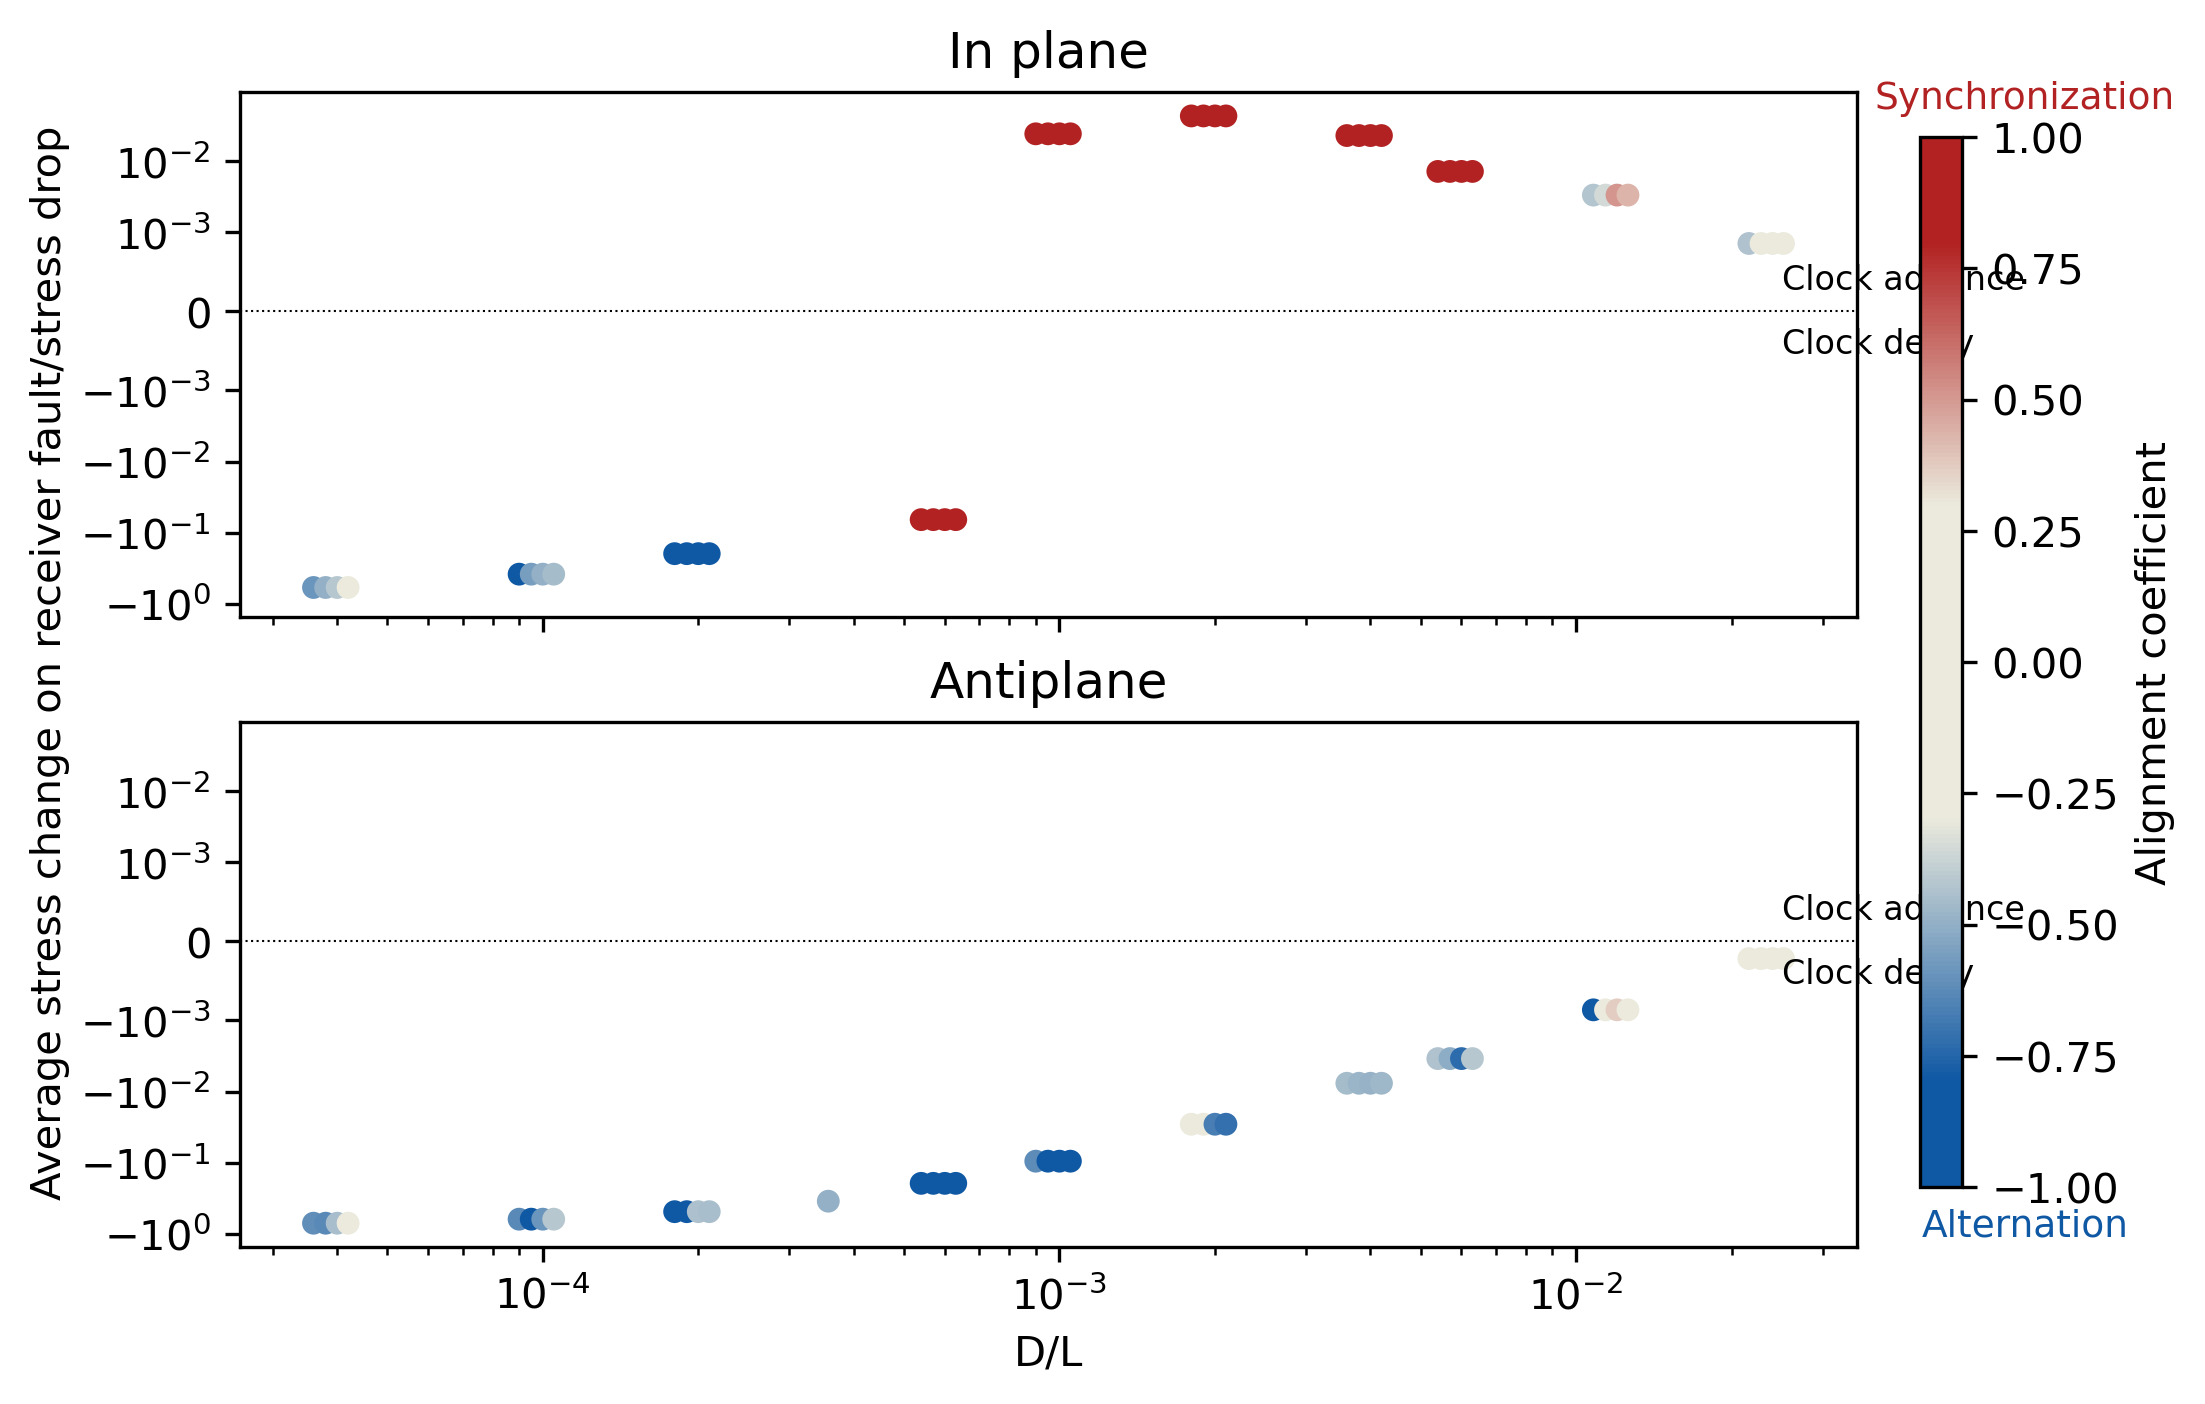

In [48]:
corr_data = pd.read_csv("code_output_data/corr_coefficient.csv")
order_data = pd.read_csv("code_output_data/order_parameter_event_times.csv")


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5), dpi=300, sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.2)

D_values_json = np.sort(
    order_data[order_data["Loading"].str.strip() == "In plane"]["D"].unique()
)[: len(inplane_full)]

avg_stress_inplane = {}
for i, curve in enumerate(inplane_full):
    if i >= len(D_values_json):
        break
    y = [point[1] for point in curve]
    D = D_values_json[i]
    avg_stress_inplane[D] = np.mean(y)

inplane_order = order_data[order_data["Loading"].str.strip() == "In plane"].copy()
dc_values = sorted(inplane_order["Dc"].unique())
n_dc = len(dc_values)

for dc_idx, dc_value in enumerate(dc_values):
    dc_subset = inplane_order[inplane_order["Dc"] == dc_value]
    for _, row in dc_subset.iterrows():
        D = row["D"]
        if D in avg_stress_inplane:
            order = row["Alignment coefficient"]
            color = custom_cmap((order + 1) / 2)
            jitter = 1 + (dc_idx - n_dc / 2) * 0.05
            ax1.scatter(
                (D / L) * jitter,
                avg_stress_inplane[D],
                c=[color],
                s=30,
                edgecolor="none",
            )

ax1.set_xscale("log")
ax1.set_yscale("symlog", linthresh=0.001)
ax1.set_title("In plane")

D_values_json_anti = np.sort(
    order_data[order_data["Loading"].str.strip() == "Antiplane"]["D"].unique()
)[: len(antiplane_full)]

avg_stress_antiplane = {}
for i, curve in enumerate(antiplane_full):
    if i >= len(D_values_json_anti):
        break
    y = [point[1] for point in curve]
    D = D_values_json_anti[i]
    avg_stress_antiplane[D] = np.mean(y)

antiplane_order = order_data[order_data["Loading"].str.strip() == "Antiplane"].copy()
dc_values_anti = sorted(antiplane_order["Dc"].unique())
n_dc_anti = len(dc_values_anti)

for dc_idx, dc_value in enumerate(dc_values_anti):
    dc_subset = antiplane_order[antiplane_order["Dc"] == dc_value]
    for _, row in dc_subset.iterrows():
        D = row["D"]
        if D in avg_stress_antiplane:
            order = row["Alignment coefficient"]
            color = custom_cmap((order + 1) / 2)
            jitter = 1 + (dc_idx - n_dc_anti / 2) * 0.05
            ax2.scatter(
                (D / L) * jitter,
                avg_stress_antiplane[D],
                c=[color],
                s=30,
                edgecolor="none",
            )

ax2.set_xscale("log")
ax2.set_yscale("symlog", linthresh=0.001)
ax2.set_xlabel("D/L")
ax2.set_title("Antiplane")

fig.text(
    0.02,
    0.5,
    "Average stress change on receiver fault/stress drop",
    va="center",
    rotation="vertical",
    fontsize=10,
)

sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=-1, vmax=1))
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Alignment coefficient")
cbar.ax.text(
    2.5,
    1.02,
    "Synchronization",
    ha="center",
    va="bottom",
    fontsize=9,
    transform=cbar.ax.transAxes,
    color="firebrick",
)
cbar.ax.text(
    2.5,
    -0.02,
    "Alternation",
    ha="center",
    va="top",
    fontsize=9,
    transform=cbar.ax.transAxes,
    color="#0F58A4",
)

ax2.set_xscale("log")
ax2.set_yscale("symlog", linthresh=0.001)
ax2.set_xlabel("D/L")
ax2.set_title("Antiplane")
ax2.axhline(0, color="black", lw=0.5, linestyle=":")
ax2.text(0.025, 0.0002, "Clock advance", fontsize=8, va="bottom")
ax2.text(0.025, -0.0002, "Clock delay", fontsize=8, va="top")
ax1.axhline(0, color="black", lw=0.5, linestyle=":")
ax1.text(0.025, 0.0002, "Clock advance", fontsize=8, va="bottom")
ax1.text(0.025, -0.0002, "Clock delay", fontsize=8, va="top")

plt.subplots_adjust(right=0.89, left=0.12)
plt.savefig(
    "Summary figures/interevent_order_plots_tables/alignment_average_stress_inplane_antiplane_full_ruptures.png",
    bbox_inches="tight",
)

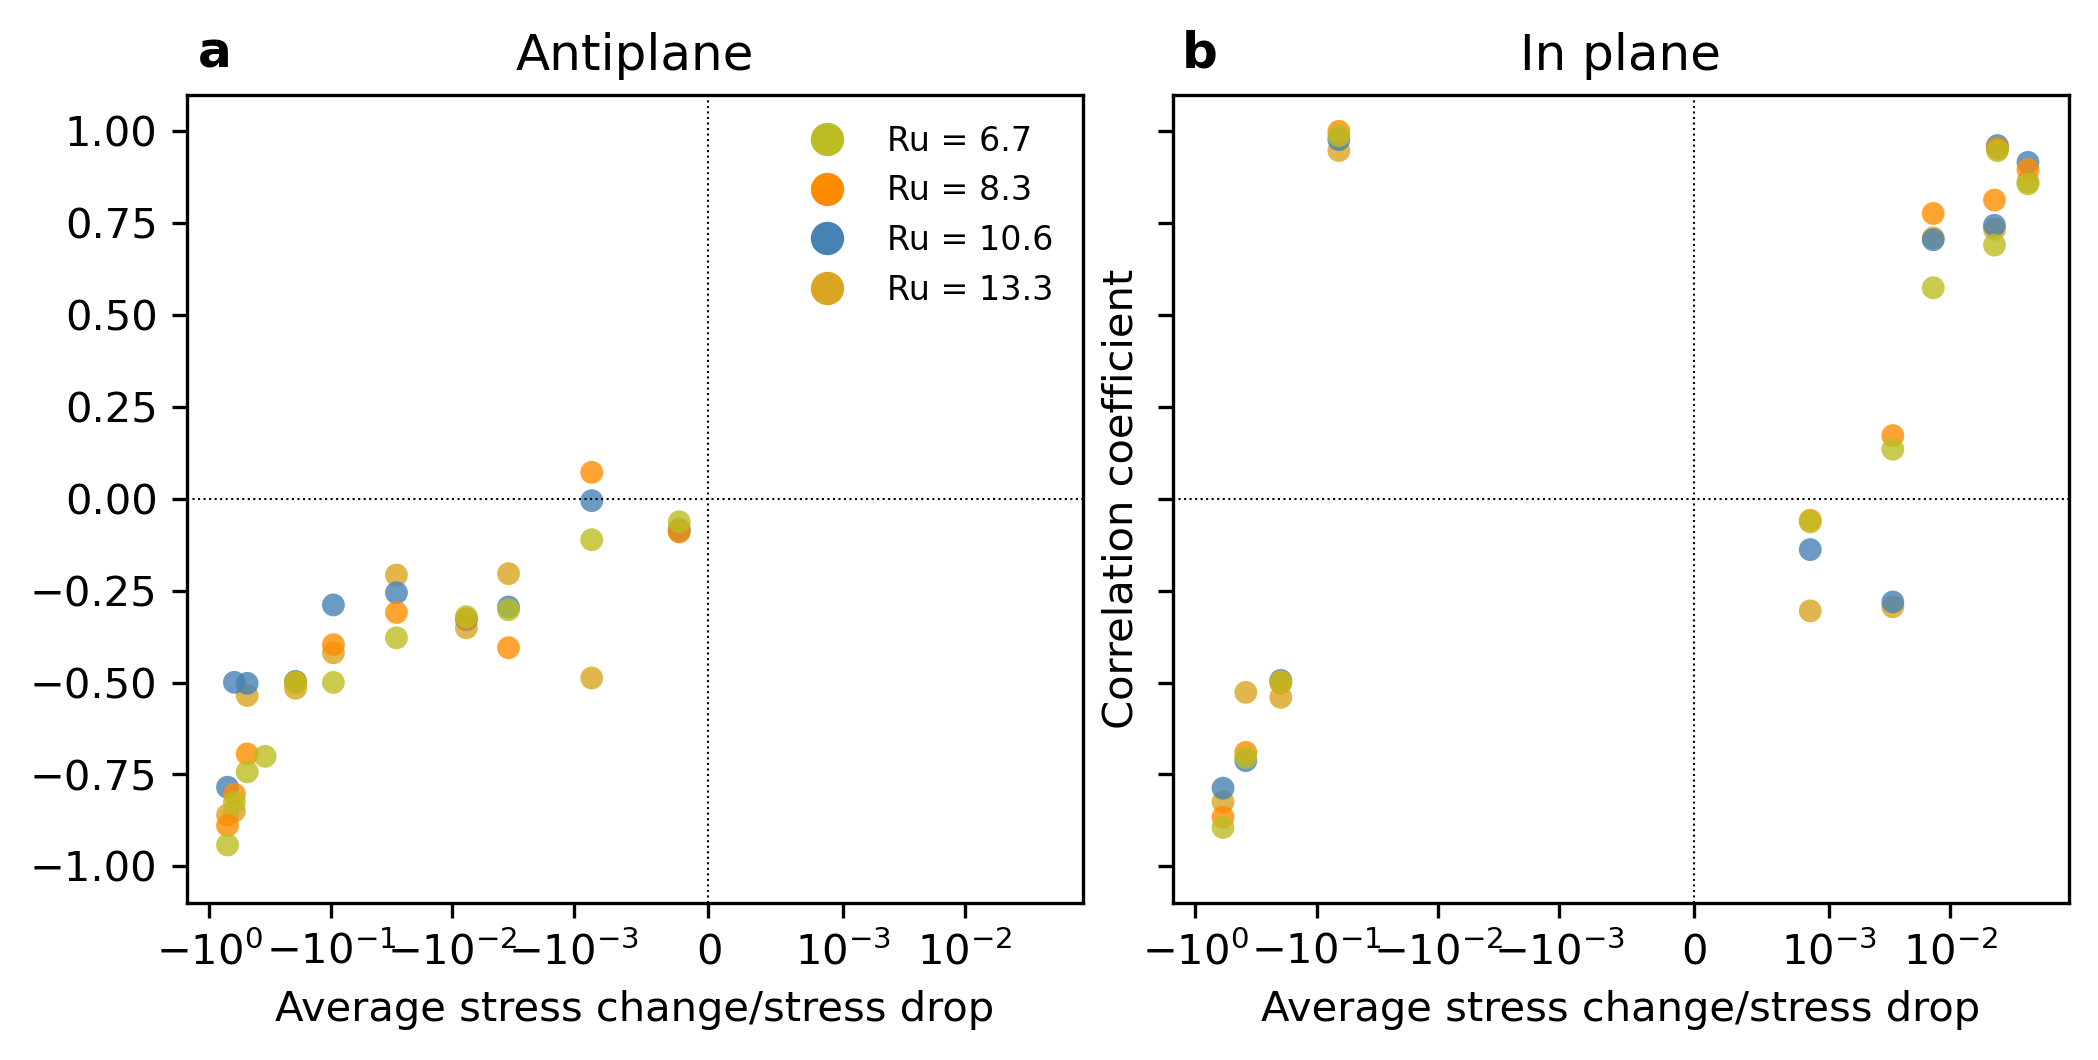

In [49]:
corr_data = pd.read_csv("code_output_data/corr_coefficient.csv")
L = 5

# Parameters for Ru calculation
shear_mod = 30e9  # Shear modulus in Pa
a = 1e-2
b = a + 4e-3
sigma_o = 100e6  # normal stress Pa
L_ru = 5000  # rate-weakening length in meters for Ru calculation

# Filter Dc > 0.005 (5mm = 0.005m)
corr_data = corr_data[corr_data["Dc"] > 0.004].copy()

dc_values_all = sorted(corr_data["Dc"].unique())
n_dc = len(dc_values_all)
dc_to_color = {
    0.010: "tab:olive",
    0.008: "darkorange",
    0.0063: "steelblue",
    0.005: "goldenrod",
}

# Calculate Ru for each Dc value
dc_to_ru = {
    dc: utils.estimate_Ru(shear_mod, dc, b, a, sigma_o, L_ru) for dc in dc_values_all
}
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(8.2, 3.5), dpi=300, sharex=True, sharey=True
)
plt.subplots_adjust(wspace=0.1)

D_values_json = np.sort(
    corr_data[corr_data["Loading"].str.strip() == "In plane"]["D"].unique()
)[: len(inplane_full)]

avg_stress_inplane = {}
for i, curve in enumerate(inplane_full):
    if i >= len(D_values_json):
        break
    y = [point[1] for point in curve]
    D = D_values_json[i]
    avg_stress_inplane[D] = np.mean(y)

# In plane
inplane_corr = corr_data[corr_data["Loading"].str.strip() == "In plane"].copy()
for dc_value in dc_values_all:
    dc_subset = inplane_corr[inplane_corr["Dc"] == dc_value]
    for _, row in dc_subset.iterrows():
        D = row["D"]
        if D in avg_stress_inplane:
            corr = row["Correlation coefficient"]
            color = dc_to_color[dc_value]
            ax2.scatter(
                avg_stress_inplane[D],
                corr,
                c=[color],
                alpha=0.8,
                s=30,
                edgecolor="none",
            )

ax2.set_xscale("symlog", linthresh=0.001)
ax2.set_ylabel("Correlation coefficient")
ax2.set_xlabel("Average stress change/stress drop")
ax2.set_title("In plane")
ax2.axvline(0, color="black", lw=0.5, linestyle=":")
ax2.axhline(0, color="black", lw=0.5, linestyle=":")
ax2.set_ylim(-1.1, 1.1)

# Antiplane
D_values_json_anti = np.sort(
    corr_data[corr_data["Loading"].str.strip() == "Antiplane"]["D"].unique()
)[: len(antiplane_full)]

avg_stress_antiplane = {}
for i, curve in enumerate(antiplane_full):
    if i >= len(D_values_json_anti):
        break
    y = [point[1] for point in curve]
    D = D_values_json_anti[i]
    avg_stress_antiplane[D] = np.mean(y)

antiplane_corr = corr_data[corr_data["Loading"].str.strip() == "Antiplane"].copy()
for dc_value in dc_values_all:
    dc_subset = antiplane_corr[antiplane_corr["Dc"] == dc_value]
    for _, row in dc_subset.iterrows():
        D = row["D"]
        if D in avg_stress_antiplane:
            corr = row["Correlation coefficient"]
            color = dc_to_color[dc_value]
            ax1.scatter(
                avg_stress_antiplane[D],
                corr,
                c=[color],
                alpha=0.8,
                s=30,
                edgecolor="none",
            )

ax1.set_xscale("symlog", linthresh=0.001)
ax1.set_xlabel("Average stress change/stress drop")
ax1.set_title("Antiplane")
ax1.axvline(0, color="black", lw=0.5, linestyle=":")
ax1.axhline(0, color="black", lw=0.5, linestyle=":")
ax1.set_ylim(-1.1, 1.1)

legend_handles = []
for dc, color in dc_to_color.items():
    ru = dc_to_ru[dc]
    legend_handles.append(
        matplotlib.lines.Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=color,
            markeredgecolor="none",
            markersize=8,
            label=f"Ru = {ru:.1f}",
        )
    )

ax1.legend(handles=legend_handles, frameon=False, loc="upper right", fontsize=8)

# Add subplot labels
ax2.text(
    0.05,
    1.08,
    "a",
    transform=ax1.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="right",
)
ax1.text(
    0.05,
    1.08,
    "b",
    transform=ax2.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="right",
)

plt.subplots_adjust(right=0.89)
plt.savefig(
    "Summary figures/interevent_order_plots_tables/average_stress_vs_correlation_by_dc_gt5mm.png",
    bbox_inches="tight",
)

In [50]:
# map view of stress kernels

# custom map (diff than sync and antisync map beware)
colors = [
    (0.0, "#0F58A4"),  # -1
    (0.1, "#0F58A4"),  # -0.8
    (0.49, "#EBEADD"),  # -0.3
    (0.51, "#EBEADD"),  # 0.3
    (0.9, "firebrick"),  # 0.8
    (1.0, "firebrick"),  # 1
]
custom_cmap = LinearSegmentedColormap.from_list("custom_RdBu", colors)


inplane_full_CS = json.load(open("stress jsons/inplane_full_CS.json"))
antiplane_full_CS = json.load(open("stress jsons/antiplane_full_CS.json"))
# structure: [x, y, z] where z is the stress change

# in plane full
x_vals_inplane = [point[0] for point in inplane_full_CS if point[2] is not None]
y_vals_inplane = [point[1] for point in inplane_full_CS if point[2] is not None]
z_vals_inplane = [point[2] for point in inplane_full_CS if point[2] is not None]

x_vals_antiplane = [point[0] for point in antiplane_full_CS if point[2] is not None]
y_vals_antiplane = [point[1] for point in antiplane_full_CS if point[2] is not None]
z_vals_antiplane = [point[2] for point in antiplane_full_CS if point[2] is not None]


#  antiplane full
x_vals_antiplane = [point[0] for point in antiplane_full_CS if point[2] is not None]
y_vals_antiplane = [point[1] for point in antiplane_full_CS if point[2] is not None]
z_vals_antiplane = [point[2] for point in antiplane_full_CS if point[2] is not None]

# In plane
# norm: 5 km = 1, so divide by 5
x_vals_inplane_norm = np.array(x_vals_inplane) / 5
y_vals_inplane_norm = np.array(y_vals_inplane) / 5

# create regular grid from data range
xi_inplane = np.linspace(min(x_vals_inplane_norm), max(x_vals_inplane_norm), 200)
yi_inplane = np.linspace(min(y_vals_inplane_norm), max(y_vals_inplane_norm), 200)
xi_grid_inplane, yi_grid_inplane = np.meshgrid(xi_inplane, yi_inplane)

# interp onto regular grid
zi_grid_inplane = griddata(
    (x_vals_inplane_norm, y_vals_inplane_norm),
    z_vals_inplane,
    (xi_grid_inplane, yi_grid_inplane),
    method="linear",
)

# Antiplane
# already normalized (5 km = 1)
xi_antiplane = np.linspace(min(x_vals_antiplane), max(x_vals_antiplane), 200)
yi_antiplane = np.linspace(min(y_vals_antiplane), max(y_vals_antiplane), 200)
xi_grid_antiplane, yi_grid_antiplane = np.meshgrid(xi_antiplane, yi_antiplane)

# interp onto regular grid
zi_grid_antiplane = griddata(
    (x_vals_antiplane, y_vals_antiplane),
    z_vals_antiplane,
    (xi_grid_antiplane, yi_grid_antiplane),
    method="linear",
)

In [51]:
# map view of stress kernels for partial ruptures
inplane_partial_CS = json.load(open("stress jsons/inplane_partial_CS.json"))
antiplane_partial_CS = json.load(open("stress jsons/antiplane_partial_CS.json"))

# in plane partial
x_vals_inplane_partial = [
    point[0] for point in inplane_partial_CS if point[2] is not None
]
y_vals_inplane_partial = [
    point[1] for point in inplane_partial_CS if point[2] is not None
]
z_vals_inplane_partial = [
    point[2] for point in inplane_partial_CS if point[2] is not None
]

x_vals_antiplane_partial = [
    point[0] for point in antiplane_partial_CS if point[2] is not None
]
y_vals_antiplane_partial = [
    point[1] for point in antiplane_partial_CS if point[2] is not None
]
z_vals_antiplane_partial = [
    point[2] for point in antiplane_partial_CS if point[2] is not None
]

# antiplane partial
x_vals_antiplane_partial = [
    point[0] for point in antiplane_partial_CS if point[2] is not None
]
y_vals_antiplane_partial = [
    point[1] for point in antiplane_partial_CS if point[2] is not None
]
z_vals_antiplane_partial = [
    point[2] for point in antiplane_partial_CS if point[2] is not None
]

# In plane

# create regular grid from data range
xi_inplane_partial = np.linspace(
    min(x_vals_inplane_partial), max(x_vals_inplane_partial), 200
)
yi_inplane_partial = np.linspace(
    min(y_vals_inplane_partial), max(y_vals_inplane_partial), 200
)
xi_grid_inplane_partial, yi_grid_inplane_partial = np.meshgrid(
    xi_inplane_partial, yi_inplane_partial
)

# interp onto regular grid
zi_grid_inplane_partial = griddata(
    (x_vals_inplane_partial, y_vals_inplane_partial),
    z_vals_inplane_partial,
    (xi_grid_inplane_partial, yi_grid_inplane_partial),
    method="linear",
)

# Antiplane
xi_antiplane_partial = np.linspace(
    min(x_vals_antiplane_partial), max(x_vals_antiplane_partial), 200
)
yi_antiplane_partial = np.linspace(
    min(y_vals_antiplane_partial), max(y_vals_antiplane_partial), 200
)
xi_grid_antiplane_partial, yi_grid_antiplane_partial = np.meshgrid(
    xi_antiplane_partial, yi_antiplane_partial
)

# interp onto regular grid
zi_grid_antiplane_partial = griddata(
    (x_vals_antiplane_partial, y_vals_antiplane_partial),
    z_vals_antiplane_partial,
    (xi_grid_antiplane_partial, yi_grid_antiplane_partial),
    method="linear",
)

### Stress change - full ruptures

In [52]:
corr_data = pd.read_csv("code_output_data/corr_coefficient.csv")
dc_value = 0.01
L = 5

inplane_corr = corr_data[
    (corr_data["Loading"].str.strip() == "In plane") & (corr_data["Dc"] == dc_value)
].copy()
inplane_corr = inplane_corr.sort_values("D")
corr_by_D_inplane = dict(
    zip(inplane_corr["D"], inplane_corr["Correlation coefficient"])
)
D_values_inplane = inplane_corr["D"].values

antiplane_corr = corr_data[
    (corr_data["Loading"].str.strip() == "Antiplane") & (corr_data["Dc"] == dc_value)
].copy()
antiplane_corr = antiplane_corr.sort_values("D")
corr_by_D_antiplane = dict(
    zip(antiplane_corr["D"], antiplane_corr["Correlation coefficient"])
)
D_values_antiplane = antiplane_corr["D"].values

IndexError: index 10 is out of bounds for axis 0 with size 10

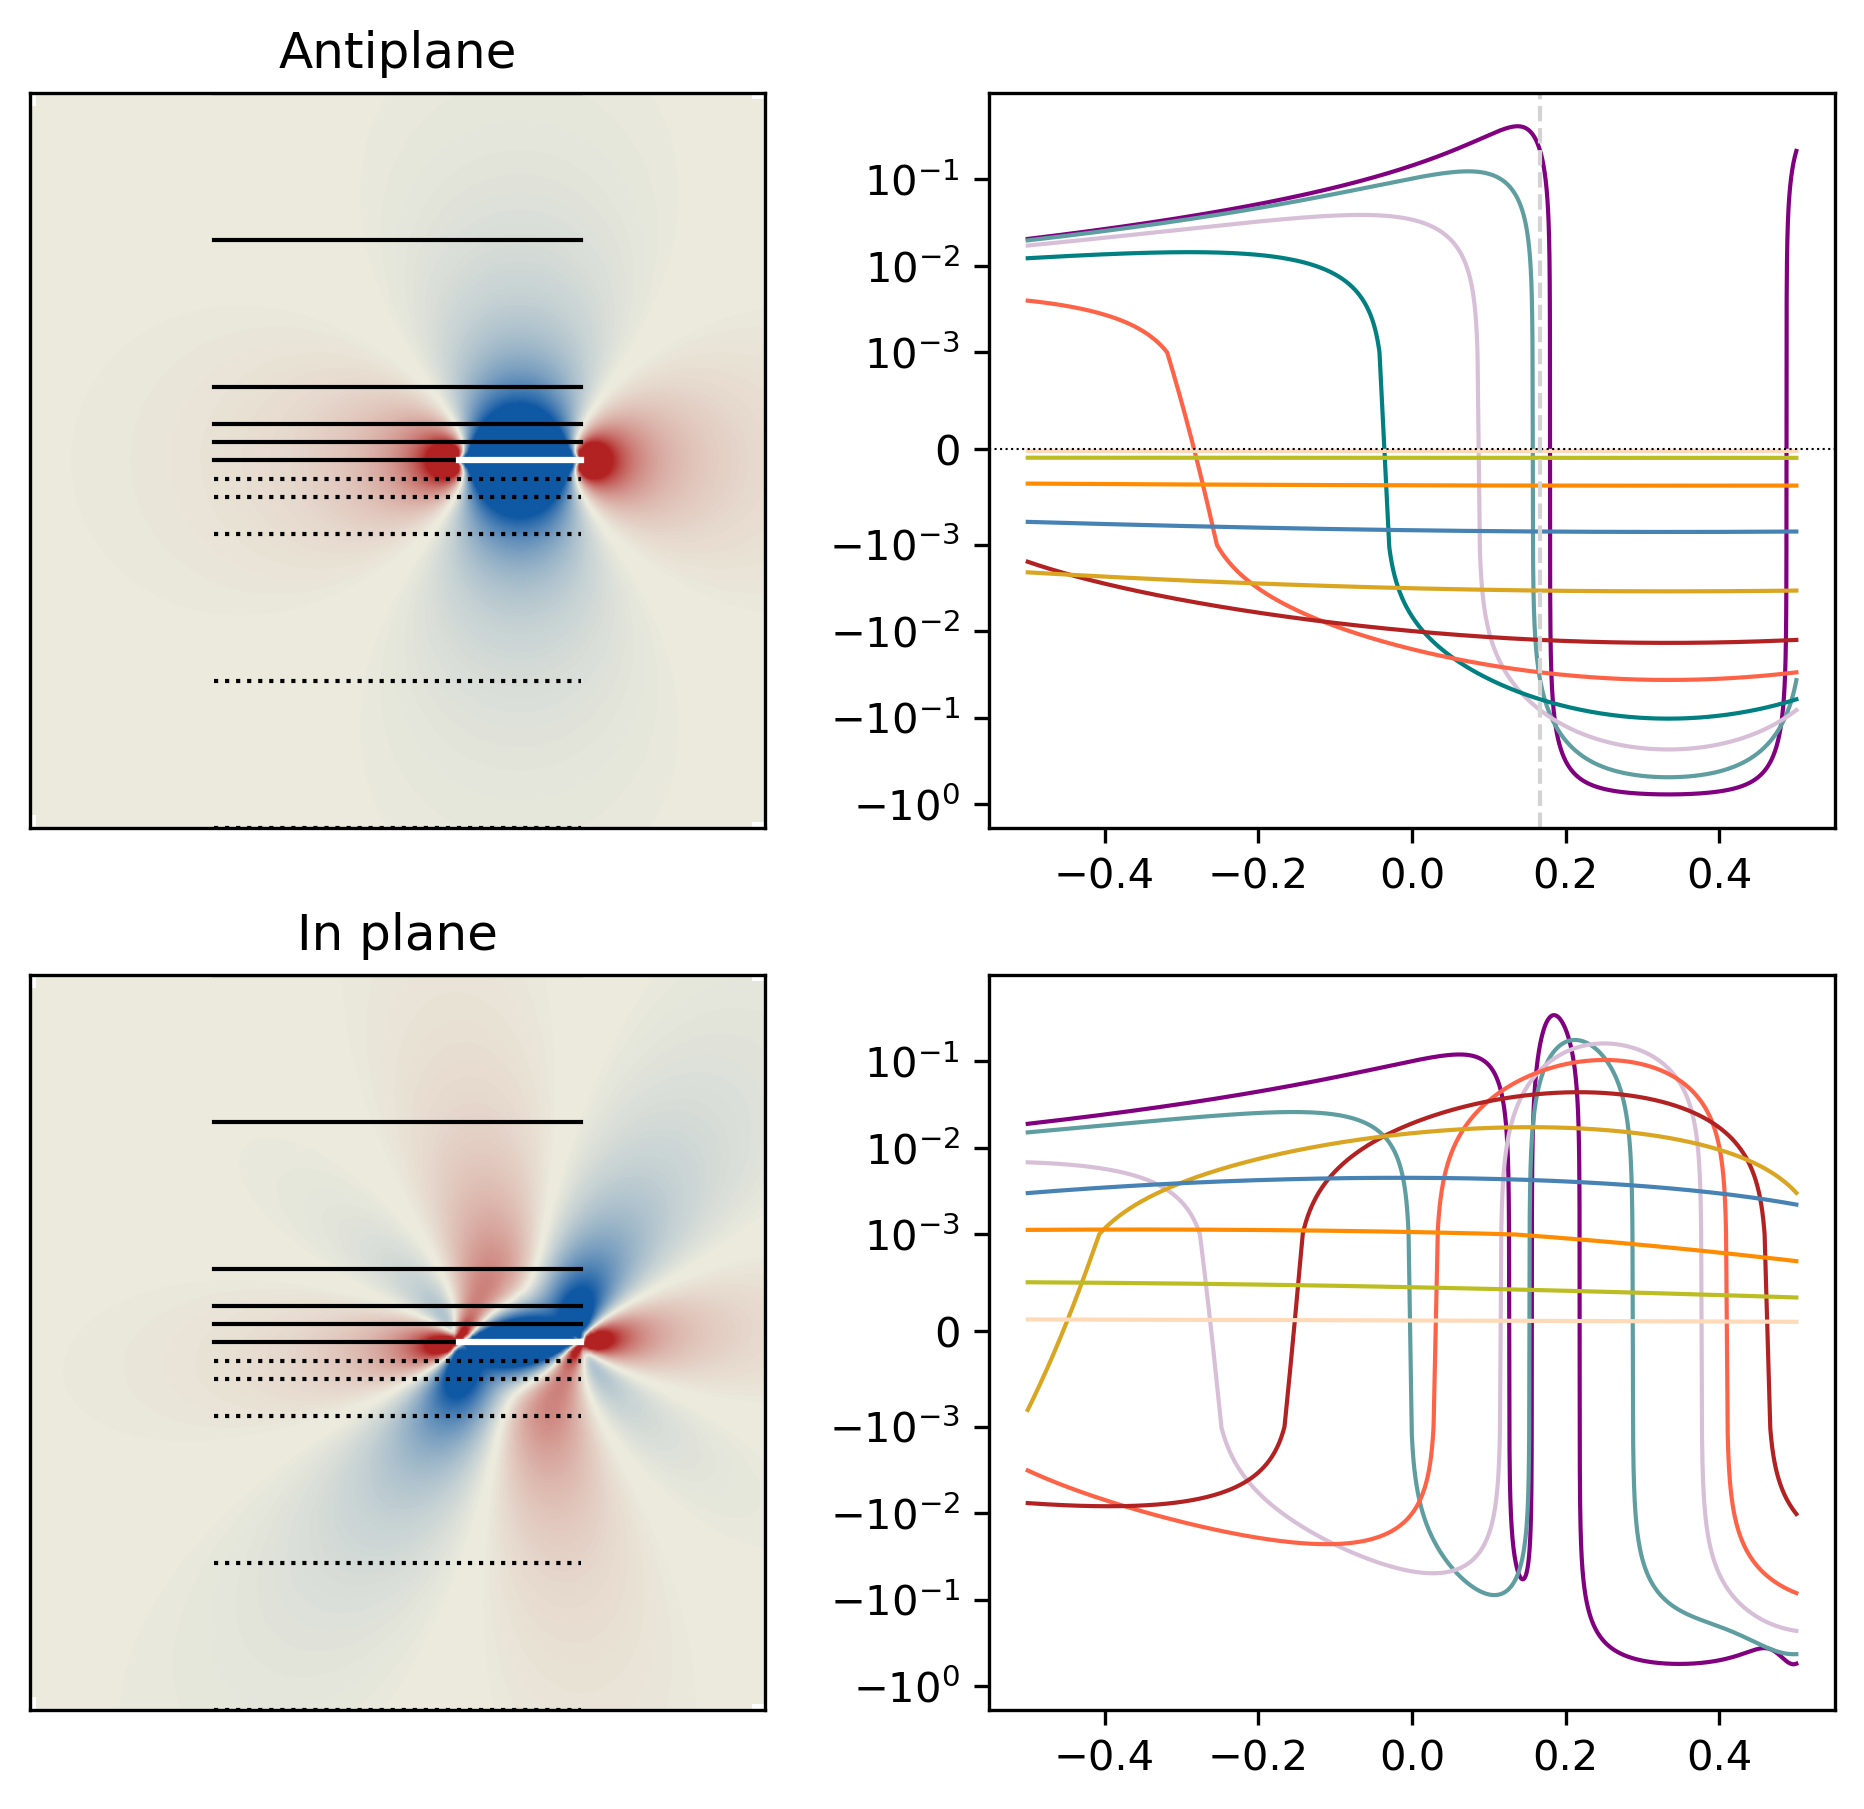

In [53]:
fig, axes = plt.subplots(
    2, 2, figsize=(8, 7), dpi=300, gridspec_kw={"width_ratios": [1, 1]}
)
ax_antiplane_img = axes[0, 0]  # Top left: Antiplane image with lines
ax_antiplane_lines = axes[0, 1]  # Top right: Antiplane lines only
ax_inplane_img = axes[1, 0]  # Bottom left: In plane image with lines
ax_inplane_lines = axes[1, 1]  # Bottom right: In plane lines only

ax_inplane_lines.sharex(ax_antiplane_lines)
ax_inplane_lines.sharey(ax_antiplane_lines)

# Use L = 5 km for D/L calculation
L = 5

# D colors for line plots
D_colors = [
    "purple",
    "cadetblue",
    "thistle",
    "teal",
    "tomato",
    "firebrick",
    "goldenrod",
    "steelblue",
    "darkorange",
    "tab:olive",
    "peachpuff",
]
all_DL_values = sorted(set(list(D_values_inplane / L) + list(D_values_antiplane / L)))
DL_to_color = {}
for i, dl in enumerate(all_DL_values):
    DL_to_color[dl] = D_colors[i % len(D_colors)]

im_antiplane = ax_antiplane_img.imshow(
    zi_grid_antiplane_partial,
    extent=[
        min(x_vals_antiplane_partial),
        max(x_vals_antiplane_partial),
        min(y_vals_antiplane_partial),
        max(y_vals_antiplane_partial),
    ],
    origin="lower",
    aspect="equal",
    interpolation="bilinear",
    cmap=custom_cmap,
)

# Source fault line: left two-thirds black, right third white
ax_antiplane_img.plot([-0.5, 1 / 6], [0, 0], color="black", linewidth=1)
ax_antiplane_img.plot([1 / 6, 0.5], [0, 0], color="white", linewidth=1.5)

# Black lines at positive y values
y_lines = [0.05, 0.1, 0.2, 0.6, 1.0]
for y_val in y_lines:
    ax_antiplane_img.plot([-0.5, 0.5], [y_val, y_val], color="black", linewidth=1)

# Dotted lines at negative y values (mirrored)
for y_val in y_lines:
    ax_antiplane_img.plot(
        [-0.5, 0.5], [-y_val, -y_val], color="black", linewidth=1, linestyle=":"
    )

ax_antiplane_img.set_title("Antiplane")
ax_antiplane_img.set_xticks([])
ax_antiplane_img.set_yticks([])

# Top right: Antiplane line plot
lines_antiplane = []
labels_antiplane = []
for i, curve in enumerate(antiplane_partial):
    x = [point[0] for point in curve]
    y = [point[1] for point in curve]
    D = D_values_antiplane[i]
    DL = D / 5
    color = DL_to_color[DL]
    (line,) = ax_antiplane_lines.plot(x, y, lw=1, label=f"D/L={DL:.2g}", color=color)
    lines_antiplane.append(line)
    labels_antiplane.append(f"D/L={DL:.2g}")

ax_antiplane_lines.axhline(0, color="black", lw=0.5, linestyle=":")
ax_antiplane_lines.axvline(1 / 6, color="lightgray", lw=1, linestyle="--")
ax_antiplane_lines.set_yscale("symlog", linthresh=0.001)

im_inplane = ax_inplane_img.imshow(
    zi_grid_inplane_partial,
    extent=[
        min(x_vals_inplane_partial),
        max(x_vals_inplane_partial),
        min(y_vals_inplane_partial),
        max(y_vals_inplane_partial),
    ],
    origin="lower",
    aspect="equal",
    interpolation="bilinear",
    cmap=custom_cmap,
)

# Source fault line: left two-thirds black, right third white
ax_inplane_img.plot([-0.5, 1 / 6], [0, 0], color="black", linewidth=1)
ax_inplane_img.plot([1 / 6, 0.5], [0, 0], color="white", linewidth=1.5)

# receiver faults
for y_val in y_lines:
    ax_inplane_img.plot([-0.5, 0.5], [y_val, y_val], color="black", linewidth=1)

# receivers mirrorred
for y_val in y_lines:
    ax_inplane_img.plot(
        [-0.5, 0.5], [-y_val, -y_val], color="black", linewidth=1, linestyle=":"
    )

ax_inplane_img.set_title("In plane")
ax_inplane_img.set_xticks([])
ax_inplane_img.set_yticks([])

lines_inplane = []
labels_inplane = []
for i, curve in enumerate(inplane_partial):
    x = [point[0] for point in curve]
    y = [point[1] for point in curve]
    D = D_values_inplane[i]
    DL = D / 5
    color = DL_to_color[DL]
    (line,) = ax_inplane_lines.plot(
        x, y, label=f"D/L={DL:.2g}", linewidth=1, color=color
    )
    lines_inplane.append(line)
    labels_inplane.append(f"D/L={DL:.2g}")

ax_inplane_lines.set_yscale("symlog", linthresh=0.001)
ax_inplane_lines.set_xlabel("Distance along rate-weakening patch")
ax_inplane_lines.axhline(0, color="black", lw=0.5, linestyle=":")
ax_inplane_lines.axvline(1 / 6, color="lightgray", lw=1, linestyle="--")

fig.text(
    0.49,
    0.5,
    "Stress change on receiver fault/stress drop",
    rotation=90,
    va="center",
    ha="center",
    fontsize=10,
)

cax = fig.add_axes([0.14, 0.05, 0.3, 0.02])
cbar = fig.colorbar(im_inplane, cax=cax, orientation="horizontal")
cbar.set_label("")
cbar.set_ticks([])
cbar.ax.text(
    0,
    -0.3,
    "Further from\nfailure",
    transform=cbar.ax.transAxes,
    ha="left",
    va="top",
    color="steelblue",
)
cbar.ax.text(
    1,
    -0.3,
    "Closer to\nfailure",
    transform=cbar.ax.transAxes,
    ha="right",
    va="top",
    color="firebrick",
)

all_lines = lines_inplane + lines_antiplane
all_labels = labels_inplane + labels_antiplane
seen = set()
unique_lines = []
unique_labels = []
for line, label in zip(all_lines, all_labels):
    if label not in seen:
        seen.add(label)
        unique_lines.append(line)
        unique_labels.append(label)

fig.legend(
    unique_lines,
    unique_labels,
    loc="center left",
    bbox_to_anchor=(0.9, 0.5),
    ncol=1,
    fontsize=9,
    frameon=False,
)

# Add subplot labels
ax_antiplane_img.text(
    0.05,
    1.08,
    "a",
    transform=ax_antiplane_img.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="right",
)
ax_antiplane_lines.text(
    0.05,
    1.08,
    "b",
    transform=ax_antiplane_lines.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="right",
)
ax_inplane_img.text(
    0.05,
    1.08,
    "c",
    transform=ax_inplane_img.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="right",
)
ax_inplane_lines.text(
    0.05,
    1.08,
    "d",
    transform=ax_inplane_lines.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="right",
)

plt.subplots_adjust(bottom=0.1, wspace=0.3, hspace=0.1)
plt.savefig(
    "Summary figures/interevent_order_plots_tables/partial_ruptures_CS.png",
    bbox_inches="tight",
)

### Stress change - partial ruptures

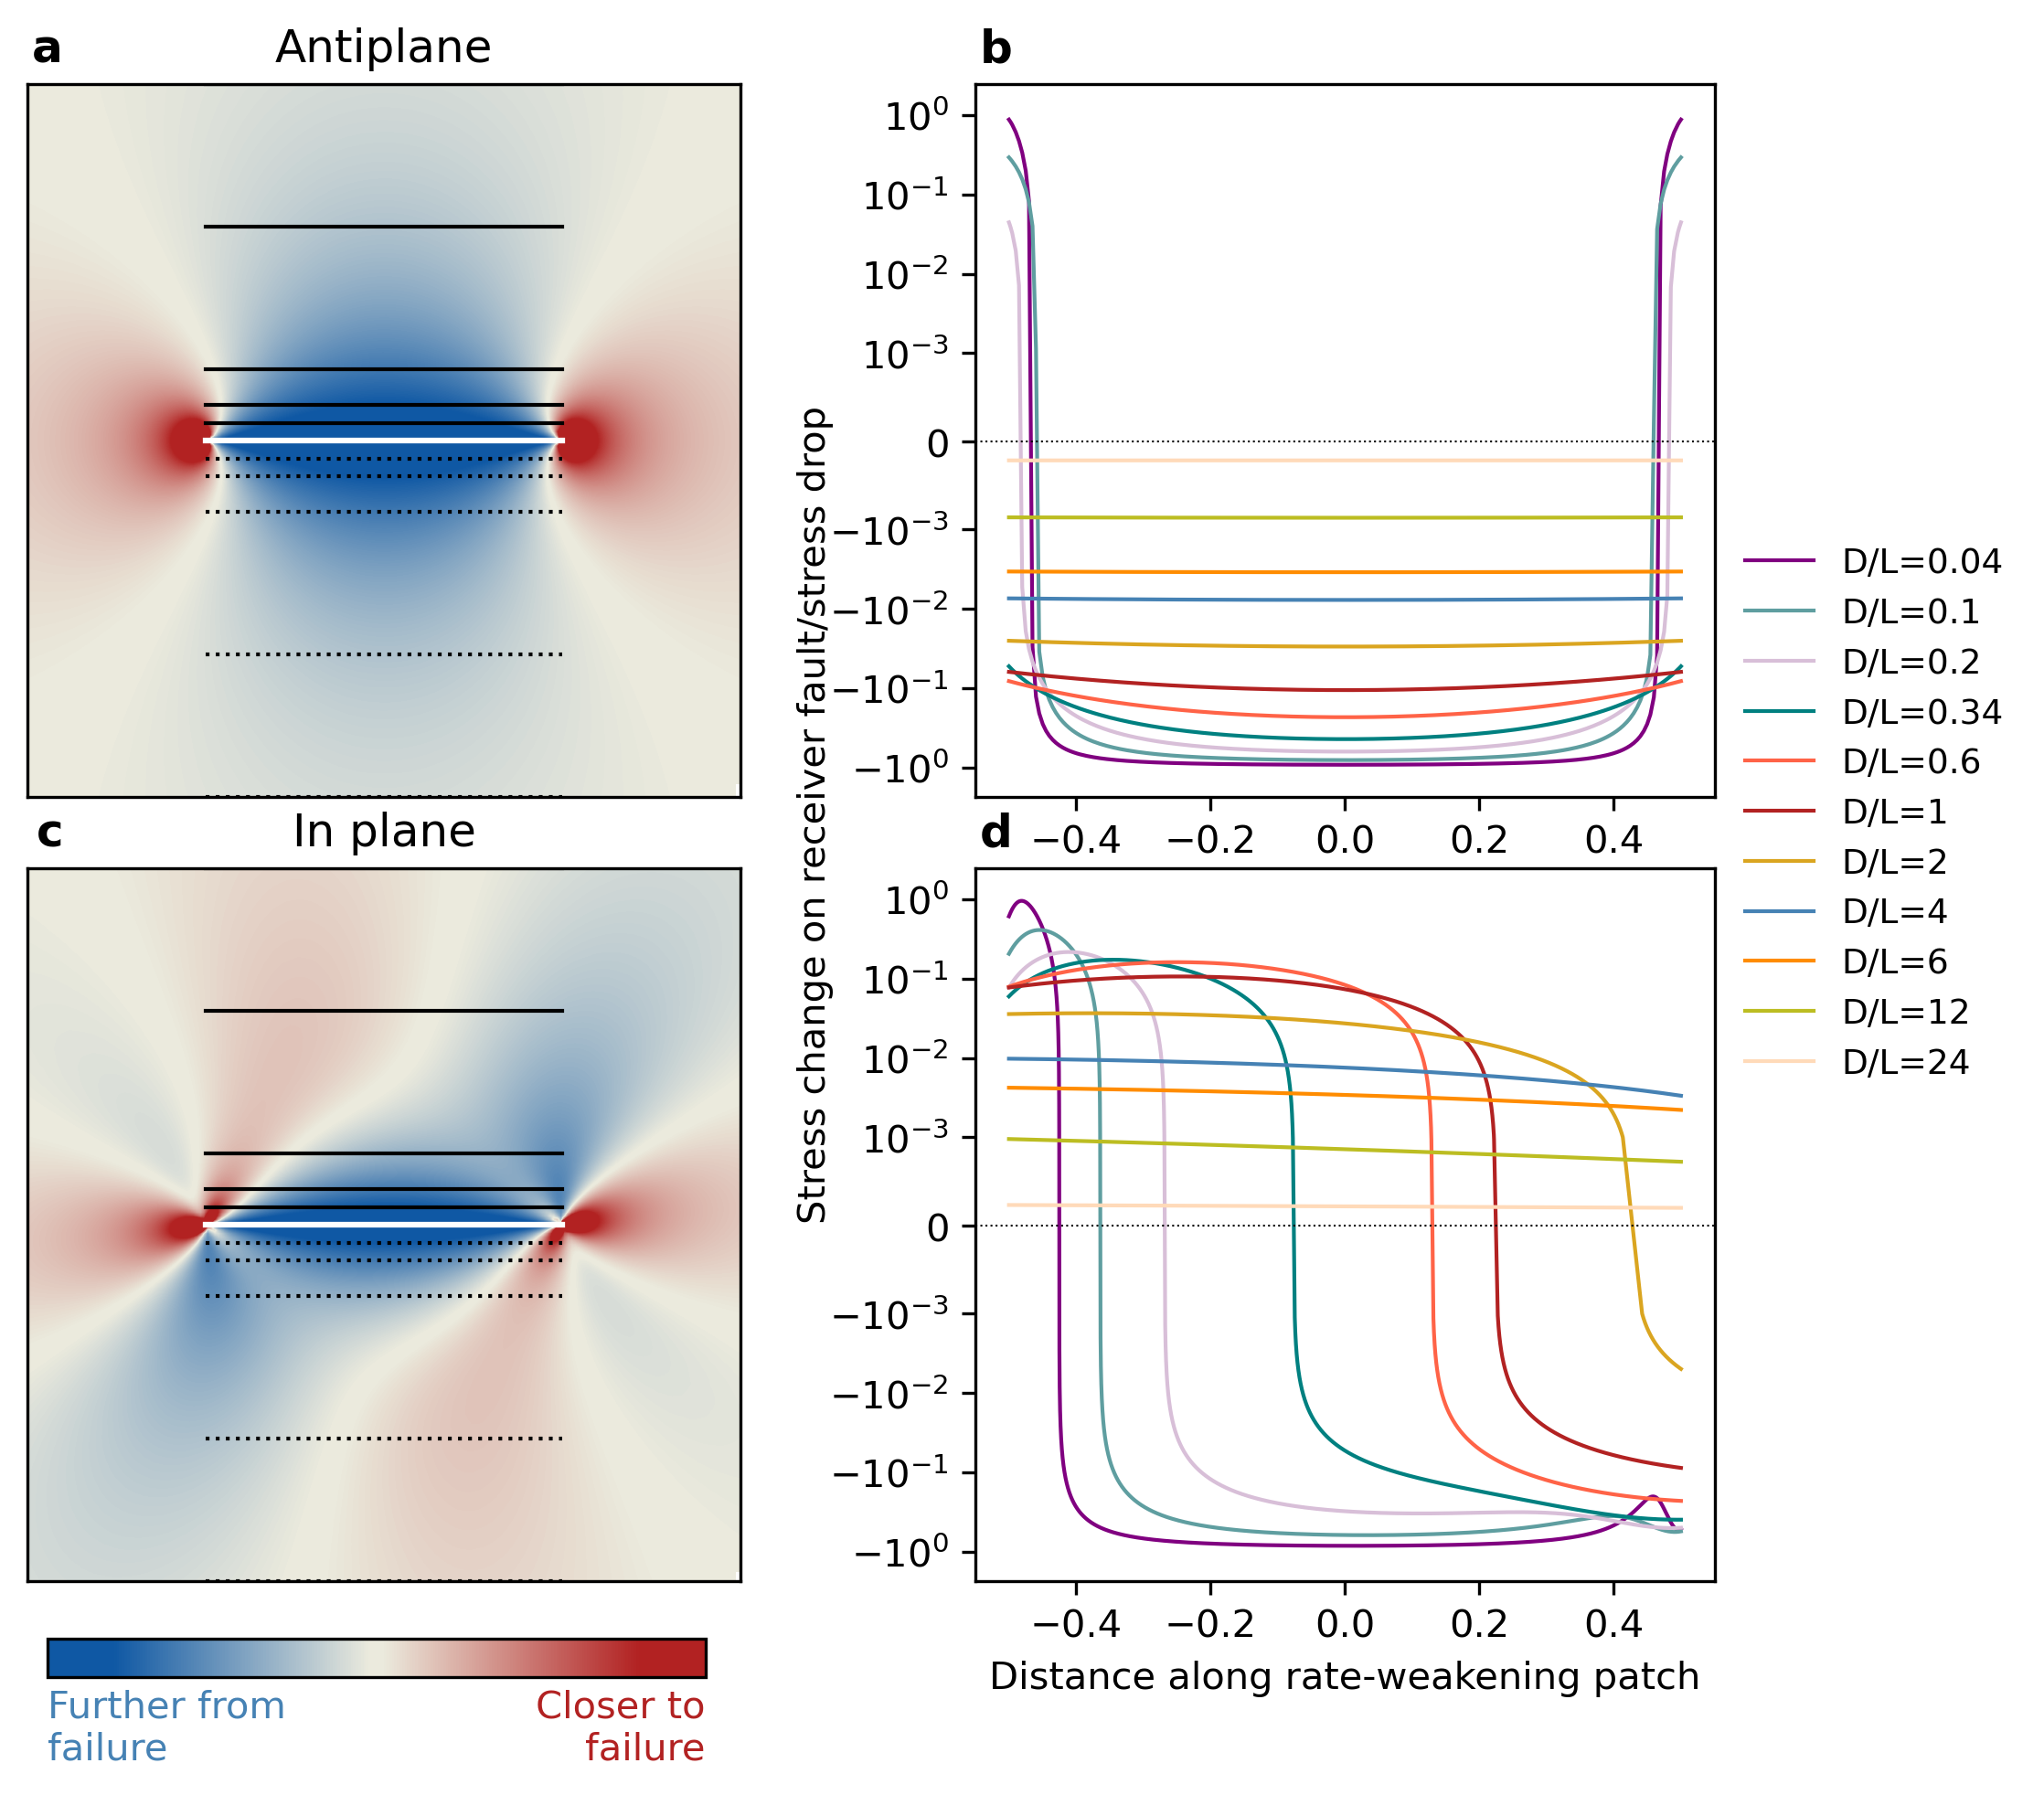

In [ ]:
fig, axes = plt.subplots(
    2, 2, figsize=(8, 7), dpi=300, gridspec_kw={"width_ratios": [1, 1]}
)
ax_antiplane_img = axes[0, 0]  # Top left: Antiplane image with lines
ax_antiplane_lines = axes[0, 1]  # Top right: Antiplane lines only
ax_inplane_img = axes[1, 0]  # Bottom left: In plane image with lines
ax_inplane_lines = axes[1, 1]  # Bottom right: In plane lines only

ax_inplane_lines.sharex(ax_antiplane_lines)
ax_inplane_lines.sharey(ax_antiplane_lines)

# D colors for line plots
D_colors = [
    "purple",
    "cadetblue",
    "thistle",
    "teal",
    "tomato",
    "firebrick",
    "goldenrod",
    "steelblue",
    "darkorange",
    "tab:olive",
    "peachpuff",
]
all_DL_values = sorted(set(list(D_values_inplane / L) + list(D_values_antiplane / L)))
DL_to_color = {}
for i, dl in enumerate(all_DL_values):
    DL_to_color[dl] = D_colors[i % len(D_colors)]

x_vals_inplane_norm = np.array(x_vals_inplane) / 5
y_vals_inplane_norm = np.array(y_vals_inplane) / 5

im_antiplane = ax_antiplane_img.imshow(
    zi_grid_antiplane,
    extent=[
        min(x_vals_antiplane),
        max(x_vals_antiplane),
        min(y_vals_antiplane),
        max(y_vals_antiplane),
    ],
    origin="lower",
    aspect="equal",
    interpolation="bilinear",
    cmap=custom_cmap,
    vmin=-1,
    vmax=1,
)

ax_antiplane_img.plot([-0.5, 0.5], [0, 0], color="white", linewidth=1.5)

# Black lines at positive y values
y_lines = [0.05, 0.1, 0.2, 0.6, 1.0]
for y_val in y_lines:
    ax_antiplane_img.plot([-0.5, 0.5], [y_val, y_val], color="black", linewidth=1)

# Dotted lines at negative y values (mirrored)
for y_val in y_lines:
    ax_antiplane_img.plot(
        [-0.5, 0.5], [-y_val, -y_val], color="black", linewidth=1, linestyle=":"
    )

ax_antiplane_img.set_title("Antiplane")
ax_antiplane_img.set_xticks([])
ax_antiplane_img.set_yticks([])

# Top right: Antiplane line plot
lines_antiplane = []
labels_antiplane = []
for i, curve in enumerate(antiplane_full):
    x = [point[0] for point in curve]
    y = [point[1] for point in curve]
    D = D_values_antiplane[i]
    DL = D / L
    color = DL_to_color[DL]
    (line,) = ax_antiplane_lines.plot(x, y, lw=1, label=f"D/L={DL:.2g}", color=color)
    lines_antiplane.append(line)
    labels_antiplane.append(f"D/L={DL:.2g}")

ax_antiplane_lines.axhline(0, color="black", lw=0.5, linestyle=":")
ax_antiplane_lines.set_yscale("symlog", linthresh=0.001)

im_inplane = ax_inplane_img.imshow(
    zi_grid_inplane,
    extent=[
        min(x_vals_inplane_norm),
        max(x_vals_inplane_norm),
        min(y_vals_inplane_norm),
        max(y_vals_inplane_norm),
    ],
    origin="lower",
    aspect="equal",
    interpolation="bilinear",
    cmap=custom_cmap,
    vmin=-1,
    vmax=1,
)

# source fault  at y=0 from x=-2.5 to x=2.5 (normalized: -0.5 to 0.5)
ax_inplane_img.plot([-0.5, 0.5], [0, 0], color="white", linewidth=1.5)

# receiver faults
for y_val in y_lines:
    ax_inplane_img.plot([-0.5, 0.5], [y_val, y_val], color="black", linewidth=1)

# receivers mirrorred
for y_val in y_lines:
    ax_inplane_img.plot(
        [-0.5, 0.5], [-y_val, -y_val], color="black", linewidth=1, linestyle=":"
    )

ax_inplane_img.set_title("In plane")
ax_inplane_img.set_xticks([])
ax_inplane_img.set_yticks([])

lines_inplane = []
labels_inplane = []
for i, curve in enumerate(inplane_full):
    x = [point[0] for point in curve]
    y = [point[1] for point in curve]
    D = D_values_inplane[i]
    DL = D / L
    color = DL_to_color[DL]
    (line,) = ax_inplane_lines.plot(
        x, y, label=f"D/L={DL:.2g}", linewidth=1, color=color
    )
    lines_inplane.append(line)
    labels_inplane.append(f"D/L={DL:.2g}")

ax_inplane_lines.set_yscale("symlog", linthresh=0.001)
ax_inplane_lines.set_xlabel("Distance along rate-weakening patch")
ax_inplane_lines.axhline(0, color="black", lw=0.5, linestyle=":")

fig.text(
    0.49,
    0.5,
    "Stress change on receiver fault/stress drop",
    rotation=90,
    va="center",
    ha="center",
    fontsize=10,
)

cax = fig.add_axes([0.14, 0.05, 0.3, 0.02])
cbar = fig.colorbar(im_inplane, cax=cax, orientation="horizontal")
cbar.set_label("")
cbar.set_ticks([])
cbar.ax.text(
    0,
    -0.3,
    "Further from\nfailure",
    transform=cbar.ax.transAxes,
    ha="left",
    va="top",
    color="steelblue",
)
cbar.ax.text(
    1,
    -0.3,
    "Closer to\nfailure",
    transform=cbar.ax.transAxes,
    ha="right",
    va="top",
    color="firebrick",
)

all_lines = lines_inplane + lines_antiplane
all_labels = labels_inplane + labels_antiplane
seen = set()
unique_lines = []
unique_labels = []
for line, label in zip(all_lines, all_labels):
    if label not in seen:
        seen.add(label)
        unique_lines.append(line)
        unique_labels.append(label)

ax_antiplane_img.text(
    0.05,
    1.08,
    "a",
    transform=ax_antiplane_img.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="right",
)
ax_antiplane_lines.text(
    0.05,
    1.08,
    "b",
    transform=ax_antiplane_lines.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="right",
)
ax_inplane_img.text(
    0.05,
    1.08,
    "c",
    transform=ax_inplane_img.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="right",
)
ax_inplane_lines.text(
    0.05,
    1.08,
    "d",
    transform=ax_inplane_lines.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="right",
)

fig.legend(
    unique_lines,
    unique_labels,
    loc="center left",
    bbox_to_anchor=(0.9, 0.5),
    ncol=1,
    fontsize=9,
    frameon=False,
)
plt.subplots_adjust(bottom=0.1, wspace=0.3, hspace=0.1)
plt.savefig(
    "Summary figures/interevent_order_plots_tables/full_ruptures_CS.png",
    bbox_inches="tight",
)